In [115]:
!pip install torch-geometric
!pip install python-sat[pblib,aiger]

!rm -r ./NNSAT_Project/Cache
!rm -r ./NNSAT_Project/Checkpoints
!rm -r ./NNSAT_Project/Logs

In [116]:
import os
import re
import time
import random

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.decomposition import TruncatedSVD, PCA

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, ConcatDataset

from torch_geometric.data import HeteroData
import torch_geometric.nn as gnn
from torch_geometric.utils import scatter
from torch_geometric.loader import DataLoader

import optuna
from optuna.pruners import SuccessiveHalvingPruner
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Configuration & Setup
# ---------------------------------------------------------
# DATA_PATH = '/kaggle/input/datasets/weihengwong/dataset' 
DATA_PATH = '/kaggle/input/datasets/weihengwong/test-dataset/test_dataset'
CACHE_PATH = './NNSAT_Project/Cache' 
CHECKPOINT_PATH = './NNSAT_Project/Checkpoints' 
LOG_PATH = './NNSAT_Project/Logs'
LOAD_PATH = '/kaggle/input/datasets/weihengwong/best-sru140-model/M-Trial4-T26-D64-L3.27e-05_epoch127_BEST.pth'
LOAD_PATH_CTP = '/kaggle/input/datasets/weihengwong/ctp-mlp-model/ClauseTierPredictor-D220-Dr0.30486349258950407-L0.0010006590443426412_best.pth'
LOAD_PATH_ADM = '/kaggle/input/datasets/weihengwong/adm-mlp-model/AssignmentDecodingModel-D207-Dr0.11160159495261959-L0.0008748982734118006_best.pth'

BATCH_SIZE = 128

os.makedirs(CACHE_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

In [117]:
# Data processing
# ---------------------------------------------------------
# Data Processing Functions
# ---------------------------------------------------------

def dimacs_parser(filepath):
    """Parses a DIMACS .cnf file to extract variables, clauses, and structure."""
    try:
        with open(filepath, 'r', encoding="utf-8") as file:
            lines = file.read().split('\n')
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return 0, 0, []

    n_var = 0
    n_clause = 0
    clauses = []
    
    for line in lines:
        if not line or line[0] == "c":
            continue
            
        info = [i for i in line.split(' ') if i]

        if info[0] == "p":
            n_var = int(info[2])
            n_clause = int(info[3])
        elif line[-1] == "0" and len(line) > 1:
            clause = [int(i) for i in info[:-1]]
            clauses.append(clause)
            
    return n_var, n_clause, clauses


def read_data(folder_name, is_training=True, fixed_label=None, limit=float('inf')):
    """Unified function to read both training and testing datasets."""
    data_set = []  
    folder_path = os.path.join(DATA_PATH, folder_name)
    filenames = sorted(os.listdir(folder_path))
    
    count = 0
    for filename in filenames:
        if not filename.endswith('.cnf'):
            continue

        filepath = os.path.join(folder_path, filename)
        n_var, n_clauses, clauses = dimacs_parser(filepath)

        # Determine label based on train/test context
        if is_training:
            if '_SAT.cnf' in filename:
                label = 1
            elif '_UNSAT.cnf' in filename:
                label = 0
            else:
                continue # Skip unknown formats in training
        else:
            label = fixed_label # Use provided label for test sets

        data_set.append((clauses, n_var, label))

        count += 1
        if count == limit:
            break

    return data_set


def build_sparse_edges(clauses, n_var):
    """
    Directly builds PyTorch sparse edge indices.
    Bypasses the memory limit of creating a dense matrix first.
    """
    source_nodes = [] # Literals
    target_nodes = [] # Clauses

    for clause_idx, clause in enumerate(clauses):
        for literal in clause:
            if literal > 0:
                # Positive literals map to indices 0 to (n_var - 1)
                lit_idx = literal - 1
            else:
                # Negative literals map to indices n_var to (2*n_var - 1)
                lit_idx = n_var + abs(literal) - 1
            
            source_nodes.append(lit_idx)
            target_nodes.append(clause_idx)
            
    # Create [2, num_edges] tensor
    edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
    edge_attr = torch.ones(len(source_nodes), dtype=torch.float32)

    return edge_index, edge_attr

# ---------------------------------------------------------
# Unified Dataset Class
# ---------------------------------------------------------

class SATDataset(Dataset): 
    """
    A unified dataset class that handles both training and testing data,
    processing graphs into HeteroData objects and caching them to disk.
    """
    def __init__(self, data_file, is_training=True, fixed_label=None, limit=float('inf')):
        super().__init__()
        self.data_file = data_file
        self.is_training = is_training
        
        # Name the cache file uniquely based on the data type
        prefix = "train" if is_training else f"test_{fixed_label}"
        self.cache_file_path = os.path.join(CACHE_PATH, f"cached_{prefix}_{data_file}.pt")
        
        if os.path.exists(self.cache_file_path):
            print(f"Loading cached data from {self.cache_file_path}...")
            self.data_list = torch.load(self.cache_file_path, weights_only=False)
        else:
            print(f"Cache file not found. Reading and converting raw data...")
            raw_problems = read_data(data_file, is_training=is_training, fixed_label=fixed_label, limit=limit)
            self.data_list = self._process(raw_problems)

        print(f"Loaded {len(self.data_list)} samples total.")

    def _process(self, raw_problems):
        processed_list = []

        for clauses, n_var, label in raw_problems:
            n_clauses = len(clauses)
            n_literals = n_var * 2
    
            # Get edges directly (no dense matrix memory overhead)
            edge_index, edge_attr = build_sparse_edges(clauses, n_var)
    
            # Build PyTorch Geometric Heterogeneous graph
            data = HeteroData()
            data['literal'].num_nodes = n_literals
            data['clause'].num_nodes = n_clauses
            data['literal', 'to', 'clause'].edge_index = edge_index
            data['literal', 'to', 'clause'].edge_attr = edge_attr
    
            data.y = torch.tensor([label], dtype=torch.float)
            data.n_vars = torch.tensor([n_var], dtype=torch.long)
            data.n_clauses = torch.tensor([n_clauses], dtype=torch.long)

            processed_list.append(data)

        print(f"Saving processed data to {self.cache_file_path}...")
        torch.save(processed_list, self.cache_file_path)

        return processed_list
            
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]


def training_data_setup(dataset):
    train_data = SATDataset(data_file=dataset, is_training=True)
    return DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)


def testing_data_setup(sat, unsat):
    test_sat_data = SATDataset(data_file=sat, is_training=False, fixed_label=1)
    test_unsat_data = SATDataset(data_file=unsat, is_training=False, fixed_label=0)
    
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    return DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

In [118]:
# NeuroSAT class
# ==============================================================================
# 1. Helper Modules 
# ==============================================================================

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)


def flip_index(L, n_literals_list):
    device = L.device
    
    # 1. Get the number of variables (V) for each graph in the batch
    n_vars = n_literals_list // 2
    
    # 2. Create the shift values: [V1, -V1, V2, -V2, ...]
    shift_vals = torch.stack([n_vars, -n_vars], dim=1).view(-1)
    
    # 3. Create the repeat counts: [V1, V1, V2, V2, ...]
    repeat_vals = torch.stack([n_vars, n_vars], dim=1).view(-1)
    
    # 4. Interleave to get the exact shift for every single literal
    shifts = torch.repeat_interleave(shift_vals, repeat_vals)
    
    # 5. Add the shifts to a standard arange index
    flip_idx = torch.arange(L.size(0), device=device) + shifts
    
    return flip_idx

# ==============================================================================
# 2. The Core Network
# ==============================================================================

class NeuroSATNetwork(nn.Module):
    def __init__(self, d_model=128, T=26):
        super().__init__()
        self.d = d_model
        self.T = T

        self.L_init = nn.Parameter(torch.randn(1, d_model))
        self.C_init = nn.Parameter(torch.randn(1, d_model))

        self.L_msg = MLP(d_model, d_model, d_model)
        self.C_msg = MLP(d_model, d_model, d_model)

        self.L_update = nn.LSTMCell(3 * d_model, d_model)
        self.C_update = nn.LSTMCell(2 * d_model, d_model)

        self.L_norm = nn.LayerNorm(d_model)
        self.C_norm = nn.LayerNorm(d_model)
        
        self.L_vote = MLP(d_model, d_model, 1)

    def forward(self, data, return_embeddings=False):
        edge_index = data['literal', 'to', 'clause'].edge_index
        n_literals = data['literal'].num_nodes 
        n_clauses = data['clause'].num_nodes 
        n_graphs = data.num_graphs
        
        n_literals_list = torch.bincount(data['literal'].batch)      

        L_h = self.L_init.repeat(n_literals, 1) / (self.d ** 0.5)
        C_h = self.C_init.repeat(n_clauses, 1) / (self.d ** 0.5)
        L_c = torch.zeros_like(L_h)
        C_c = torch.zeros_like(C_h)

        # PRE-COMPUTE FLIP INDEX ONCE
        flip_idx = flip_index(L_h, n_literals_list)

        edge_index = edge_index.to(L_h.device)

        for t in range(self.T):
            L_pre = self.L_msg(L_h)  
            L_msgs = L_pre[edge_index[0]]  
            C_aggr = scatter(L_msgs, edge_index[1], dim=0, dim_size=n_clauses, reduce='sum') 
            
            C_input = torch.cat([C_h, C_aggr], dim=1)
            C_h, C_c = self.C_update(C_input, (C_h, C_c))
            C_h = self.C_norm(C_h)

            C_pre = self.C_msg(C_h)
            C_msgs = C_pre[edge_index[1]]
            L_aggr = scatter(C_msgs, edge_index[0], dim=0, dim_size=n_literals, reduce='sum')
            
            L_flipped = L_h[flip_idx]
            L_input = torch.cat([L_h, L_flipped, L_aggr], dim=1)
            L_h, L_c = self.L_update(L_input, (L_h, L_c))
            L_h = self.L_norm(L_h)

        L_votes = self.L_vote(L_h).squeeze(-1) 
        batch_idx = data['literal'].batch
        graph_logits = scatter(L_votes, batch_idx, dim=0, dim_size=n_graphs, reduce='mean')

        if return_embeddings:
            # 1. Use the flip_idx we pre-computed to align positive and negative votes instantly
            L_votes_flipped = L_votes[flip_idx]
            
            # 2. Average the positive and negative literal votes
            averaged_literal_votes = (L_votes + L_votes_flipped) / 2
            
            # 3. Create a mask to grab only the first half of each graph's literals (the positive ones) 
            n_vars_tensor = n_literals_list // 2
            
            # 3b. Create an alternating pattern: [True, False, True, False...]
            bool_pattern = torch.tensor([True, False], device=L_h.device).repeat(n_graphs)
            # 3c. Create the repeat counts: [V1, V1, V2, V2...]
            repeat_counts = torch.stack([n_vars_tensor, n_vars_tensor], dim=1).view(-1)
            # 3d. Interleave to generate the exact mask instantly
            pos_mask = torch.repeat_interleave(bool_pattern, repeat_counts)
            
            var_votes = averaged_literal_votes[pos_mask]

            # Return everything: Graph Votes, Literal Embeddings, Clause Embeddings, Variable Votes
            return graph_logits, L_h, C_h, var_votes
            
        return graph_logits

        
# ==============================================================================
# 3. The Orchestrator Class 
# ==============================================================================

class NeuroSAT(object):
    def __init__(self, opts):
        """
        opts should be a dictionary or object containing hyperparameters.
        """
        self.opts = opts
        self.device = opts.get('device', torch.device("cuda" if torch.cuda.is_available() else "cpu"))
        
        self.init_random_seeds()
        self.build_network()

    def init_random_seeds(self):
        seed = self.opts.get('seed', 42)
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

    def build_network(self):
        self.model = NeuroSATNetwork(
            d_model=self.opts.get('d_model', 64), 
            T=self.opts.get('T', 26)
        ).to(self.device)
        
        self.loss_fn = nn.BCEWithLogitsLoss() 
        self.optimizer = optim.Adam(
            self.model.parameters(), 
            lr=self.opts.get('learning_rate', 2e-5)
        )

    def save(self, path):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'loss': loss,
        }
        torch.save(checkpoint, path)

    def restore(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path, map_location=self.device)
            print(f"--- Checkpoint loaded. Epoch {checkpoint['epoch'] + 1} ---")
            self.model.load_state_dict(checkpoint['model_state_dict'])

    def train_epoch(self, dataloader, epoch):
        self.model.train()
        total_loss = 0
        total_samples = 0
        
        epoch_start = time.time()

        for i, batch_data in enumerate(dataloader):
            batch_data = batch_data.to(self.device)
            target = batch_data.y

            self.optimizer.zero_grad()

            outputs = self.model(batch_data)
            loss = self.loss_fn(outputs, target)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.opts.get('clip_val', 0.65))
            self.optimizer.step()

            total_loss += loss.item() * batch_data.num_graphs
            total_samples += batch_data.num_graphs

        epoch_end = time.time()
        avg_loss = total_loss / total_samples
        return avg_loss, epoch_end - epoch_start

    def test(self, dataloader):
        self.model.eval()
        total_correct = 0
        total_samples = 0
        
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch_data in dataloader:
                batch_data = batch_data.to(self.device)
                target = batch_data.y.float().view(-1)
                
                logits = self.model(batch_data).view(-1)
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(target.cpu().numpy())

                total_correct += (preds == target).sum().item()
                total_samples += batch_data.num_graphs

        accuracy = total_correct / total_samples
        return accuracy, confusion_matrix(all_labels, all_preds)

    def check_satisfaction(self, edge_index, num_clauses, assignment):
        """
        Vectorized PyTorch implementation to check if an instances is satisfied by the assignment
        """
        if not isinstance(assignment, torch.Tensor):
            assignment = torch.tensor(assignment, device=edge_index.device)
            
        flipped = 1 - assignment
        full_assignment = torch.cat([assignment, flipped], dim=0)
        
        true_literals_mask = full_assignment[edge_index[0]] == 1
        satisfied_clauses = torch.unique(edge_index[1][true_literals_mask])
        
        return len(satisfied_clauses) == num_clauses, len(satisfied_clauses)

    def find_solutions(self, batch_data):
        """
        K-Means Clustering to extract boolean assignments from the learned embeddings.
        Must be done in CPU as K-Means implementation of scikit-learn does not accept inputs on GPU.
        """
        self.model.eval()
        batch_data = batch_data.to(self.device)
        solutions = []

        with torch.no_grad():
            # Get logits, node embeddings, and node votes
            graph_logits, L_h, C_h, var_votes = self.model(batch_data, return_embeddings=True)
            
            # Split by graph in the batch
            n_lits_list = [(batch_data['literal'].batch == i).sum().item() for i in range(batch_data.num_graphs)]
            vars_per_graph = batch_data.n_vars.tolist()
            
            L_h_split = torch.split(L_h, n_lits_list)

            for i in range(batch_data.num_graphs):
                n_vars_i = vars_per_graph[i]
                num_clauses_i = (batch_data['clause'].batch == i).sum().item()
                
                # Isolate the graph's specific edge_index
                l_mask = (batch_data['literal'].batch == i)
                c_mask = (batch_data['clause'].batch == i)
                edge_index = batch_data['literal', 'to', 'clause'].edge_index
                my_edges = edge_index[:, l_mask[edge_index[0]]].clone()
                my_edges[0] -= l_mask.nonzero()[0].min().item()
                my_edges[1] -= c_mask.nonzero()[0].min().item()

                # --- K-Means Clustering ---
                embeddings_i = L_h_split[i].cpu().numpy()
                pos_emb = embeddings_i[:n_vars_i, :]
                neg_emb = embeddings_i[n_vars_i:, :]
                
                # Stack to [2 * n_vars, d_model] and cluster
                L_concat = np.concatenate([pos_emb, neg_emb], axis=0)
                kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(L_concat)
                c1, c2 = kmeans.cluster_centers_

                d1 = np.sum((pos_emb - c1)**2, axis=1) + np.sum((neg_emb - c2)**2, axis=1)
                d2 = np.sum((pos_emb - c2)**2, axis=1) + np.sum((neg_emb - c1)**2, axis=1)
                
                decode_kmeans_A = np.where(d1 > d2, 1, 0).astype(float)
                decode_kmeans_B = 1.0 - decode_kmeans_A

                satA, c_satA = self.check_satisfaction(my_edges, num_clauses_i, decode_kmeans_A)
                satB, c_satB = self.check_satisfaction(my_edges, num_clauses_i, decode_kmeans_B)
                if satA:
                    solutions.append({"assignment": decode_kmeans_A, "satisfied": True})
                elif satB:
                    solutions.append({"assignment": decode_kmeans_B, "satisfied": True})
                elif c_satA > c_satB:
                    solutions.append({"assignment": decode_kmeans_A, "satisfied": False}) # Return the best candidate
                else:
                    solutions.append({"assignment": decode_kmeans_B, "satisfied": False})

        return solutions

    def inference(self, dataloader):
        """
        Runs a full forward pass on a dataloader to extract all embeddings and votes.
        Returns: graph_votes, literal_embeddings, clause_embeddings, variable_votes, latency_ms
        """
        self.model.eval()
        
        all_graph_votes = []
        all_lit_embs = []
        all_clause_embs = []
        all_var_votes = []
        
        total_samples = 0

        torch.cuda.synchronize(self.device)
        start_time = time.perf_counter()

        with torch.no_grad():
            for batch_data in dataloader:
                batch_data = batch_data.to(self.device)

                # Get the detailed outputs from our updated forward pass
                outputs, L_h, C_h, var_votes = self.model(batch_data, return_embeddings=True)
                votes = torch.sigmoid(outputs)

                # # 1. Literals
                # n_lits_per_graph = (batch_data.n_vars * 2).tolist()
                # split_L_h = torch.split(L_h, n_lits_per_graph)
                # all_lit_embs.append([emb.cpu().numpy() for emb in split_L_h])
                
                # # 2. Clauses: Get chunk sizes using bincount (safest way in PyG)
                # n_clauses_per_graph = torch.bincount(batch_data['clause'].batch).tolist()
                # split_C_h = torch.split(C_h, n_clauses_per_graph)
                # all_clause_embs.append([emb.cpu().numpy() for emb in split_C_h])
                
                # Move to CPU immediately to save GPU RAM
                all_graph_votes.append(votes.cpu())
                all_lit_embs.append(L_h.cpu())
                all_clause_embs.append(C_h.cpu())
                all_var_votes.append(var_votes.cpu())
                
                total_samples += batch_data.num_graphs

        end_time = time.perf_counter()
        
        # Concatenate all batch lists into massive single tensors
        votes = torch.cat(all_graph_votes, dim=0)
        lit_emb = torch.cat(all_lit_embs, dim=0)
        clause_emb = torch.cat(all_clause_embs, dim=0)
        paired_var_votes = torch.cat(all_var_votes, dim=0)

        # Handle Latency Logic
        total_time_ms = (end_time - start_time) * 1000
        latency_ms = total_time_ms / max(1, total_samples)

        return votes, lit_emb, clause_emb, paired_var_votes, latency_ms

In [119]:
# training + hyper-parameter tuning

def build_model():
    # ---------------------------------------------------------
    # 1. Hyperparameters & Configuration
    # ---------------------------------------------------------
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    MODEL_NAME = "NeuroSAT_SR40"
    
    opts = {
        'd_model': 64,          # Embedding dimension (D)
        'T': 26,                # Message passing iterations
        'learning_rate': 2e-5,
        'clip_val': 0.65,       # Gradient clipping
        'seed': 42,
        'device': DEVICE
    }

    BATCH_SIZE = 128
    MAX_EPOCHS = 400
    SAVE_INTERVAL = 50
    PATIENCE_LIMIT = 10

    # ---------------------------------------------------------
    # 2. Data Preparation
    # ---------------------------------------------------------
    print("Loading datasets...")
    train_data = SATDataset(data_file="SR_Uniform_10-40_Dataset", is_training=True)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

    test_sat_data = SATDataset(data_file="40_SAT", is_training=False, fixed_label=1)
    test_unsat_data = SATDataset(data_file="40_UNSAT", is_training=False, fixed_label=0)
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    test_loader = DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

    # ---------------------------------------------------------
    # 3. Initialize Solver
    # ---------------------------------------------------------
    print(f"\nInitializing NeuroSAT on {DEVICE}...")
    solver = NeuroSAT(opts)

    # Optional: Resume from checkpoint if it exists
    best_model_path = os.path.join('./NNSAT_Project/Checkpoints', f"{MODEL_NAME}.pth")
    solver.restore(best_model_path)

    # ---------------------------------------------------------
    # 4. Training Loop
    # ---------------------------------------------------------
    max_acc = 0.0
    patience_counter = 0

    print("\nStarting Training...")
    for epoch in range(MAX_EPOCHS):
        # Train for one epoch
        avg_loss, duration = solver.train_epoch(train_loader, epoch)
        print(f"--- Epoch {epoch + 1} | Loss: {avg_loss:.4f} | Time: {duration:.2f}s ---")

        # Evaluate on the eval set
        curr_acc, conf_matrix = solver.test(test_loader)
        print(f"Validation Accuracy: {curr_acc:.4f}")

        # Periodic Saving
        if (epoch + 1) % SAVE_INTERVAL == 0:
            periodic_path = os.path.join('./NNSAT_Project/Checkpoints', f"{MODEL_NAME}_epoch_{epoch+1}.pth")
            solver.save(periodic_path)
            print(f"Saved periodic checkpoint.")

        # Best Model Tracking & Early Stopping
        if curr_acc > max_acc:
            max_acc = curr_acc
            patience_counter = 0
            
            # Save if it's the best accuracy 
            solver.save(best_model_path)
            print(f"*** New Best Model Saved! (Acc: {max_acc:.4f}) ***")
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE_LIMIT and avg_loss < 0.6:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs.")
            break

    print(f"\nTraining Complete. Best Validation Accuracy: {max_acc:.4f}")

    # ---------------------------------------------------------
    # 5. Extracting Solutions (Inference/Decoding)
    # ---------------------------------------------------------
    print("\n--- Testing Assignment Decoding ---")
    # Let's grab a single batch from the test set to decode
    test_batch = next(iter(test_loader))
    
    # find_solutions returns a list of assignments (arrays of 0s and 1s) 
    # or 'None' if it couldn't find a valid satisfying assignment
    solutions = solver.find_solutions(test_batch)
    
    solved_count = sum(1 for s in solutions if s is not None)
    total_sat_in_batch = test_batch.y.sum().item()
    
    print(f"In this batch of {BATCH_SIZE} graphs:")
    print(f"  - Actual SAT problems: {int(total_sat_in_batch)}")
    print(f"  - Successfully decoded solutions: {solved_count}")


# build_model()

import optuna
from optuna.pruners import SuccessiveHalvingPruner

def objective(trial, train_loader, test_loader, device):
    # 1. Define the hyperparameter search space for this trial
    d_model = trial.suggest_categorical('d_model', [64, 96, 128])
    T = trial.suggest_int('T', 20, 30)
    lr = trial.suggest_float('lr', 1e-5, 5e-5, log=True)

    # 2. Package into the opts dictionary for our NeuroSAT class
    opts = {
        'd_model': d_model,
        'T': T,
        'learning_rate': lr,
        'clip_val': 0.65,
        'device': device,
        'seed': 42
    }

    # 3. Initialize the solver for this trial
    solver = NeuroSAT(opts)
    
    # 4. Trial Configuration
    MAX_EPOCHS = 250
    SAVE_INTERVAL = 100
    PATIENCE_LIMIT = 10 
    
    best_acc = 0.0
    patience_counter = 0
    model_name = f"M-Trial{trial.number}-T{T}-D{d_model}-L{lr:.2e}"

    print(f"\n=== Starting Trial {trial.number}: T={T}, D={d_model}, LR={lr:.2e} ===")

    for epoch in range(MAX_EPOCHS):
        # Train and Test
        avg_loss, _ = solver.train_epoch(train_loader, epoch)
        curr_acc, _ = solver.test(test_loader)

        # Optuna pruning check (reports intermediate value to Optuna)
        trial.report(curr_acc, epoch)
        if trial.should_prune():
            print(f"Trial {trial.number} pruned by Optuna at epoch {epoch}.")
            raise optuna.exceptions.TrialPruned()

        # Update best accuracy and manage custom early stopping patience
        if curr_acc > best_acc:
            best_acc = curr_acc
            patience_counter = 0
            
            # Save the best model for this specific trial
            best_ckpt = os.path.join('./NNSAT_Project/Checkpoints', f"{model_name}_BEST.pth")
            solver.save(best_ckpt)
        else:
            patience_counter += 1

        # Periodic checkpointing 
        if (epoch + 1) % SAVE_INTERVAL == 0:
            periodic_ckpt = os.path.join('./NNSAT_Project/Checkpoints', f"{model_name}_epoch{epoch + 1}.pth")
            solver.save(periodic_ckpt)

        # Patience-based custom early stopping
        if patience_counter >= PATIENCE_LIMIT and avg_loss < 0.6:
            print(f"Trial {trial.number} stopped at epoch {epoch} due to custom patience.")
            break

    return best_acc


def auto_hyperparameter_tuning():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    BATCH_SIZE = 128
    print(f"Setting up Optuna Study on {DEVICE}...")

    # Load datasets ONCE before starting trials to save massive amounts of time
    print("Loading datasets...")
    train_data = SATDataset("SR_Uniform_10-40_Dataset", is_training=True)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

    test_sat_data = SATDataset("40_SAT", is_training=False, fixed_label=1)
    test_unsat_data = SATDataset("40_UNSAT", is_training=False, fixed_label=0)
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    test_loader = DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

    # Setup the Optuna Pruner
    pruner = SuccessiveHalvingPruner(
        min_resource=20,          # Allow trials to run for at least 20 epochs before judging them
        reduction_factor=3        # Halves the number of trials each round
    )
    
    study = optuna.create_study(direction="maximize", pruner=pruner)

    # Wrap the objective to inject the data loaders
    def wrapped_objective(trial):
        return objective(trial, train_loader, test_loader, DEVICE)

    # Run the optimization
    study.optimize(wrapped_objective, n_trials=10)
    
    print("\n==================================")
    print("Hyperparameter Tuning Complete!")
    print("Best Trial:", study.best_trial.number)
    print("Best Accuracy:", study.best_value)
    print("Best Parameters:")
    for key, value in study.best_params.items():
        print(f"    {key}: {value}")
    print("==================================")

# auto_hyperparameter_tuning()

In [120]:
# model testing 

import os
import torch
from torch.utils.data import ConcatDataset
from torch_geometric.loader import DataLoader

def load_and_test():
    # ---------------------------------------------------------
    # 1. Match Training Hyperparameters
    # ---------------------------------------------------------
    opts = {
        'd_model': 64,         
        'T': 26,                
        'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        'seed': 42
    }
    BATCH_SIZE = 128

    # ---------------------------------------------------------
    # 2. Setup the Test Data
    # ---------------------------------------------------------
    print("Loading test datasets...")
    
    # Load SAT and UNSAT datasets separately, then merge them
    test_sat_data = SATDataset(data_file="Test_40_SAT", is_training=False, fixed_label=1)
    test_unsat_data = SATDataset(data_file="Test_40_UNSAT", is_training=False, fixed_label=0)
    
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    test_loader = DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

    # ---------------------------------------------------------
    # 3. Initialize and Load the Model
    # ---------------------------------------------------------
    print(f"Initializing NeuroSAT on {opts['device']}...")
    solver = NeuroSAT(opts)

    print(f"Loading weights from {LOAD_PATH}...")
    solver.restore(LOAD_PATH)

    # ---------------------------------------------------------
    # 4. Run Evaluation
    # ---------------------------------------------------------
    print("\nRunning test evaluation...")
    accuracy, conf_matrix = solver.test(test_loader)
    
    print("\n--- Test Results ---")
    print(f"Overall Accuracy:  {accuracy * 100:.2f}%")
    print("Confusion Matrix (TN, FP | FN, TP):")
    print(conf_matrix)

    # ---------------------------------------------------------
    # 5. Extracting an actual solution
    # ---------------------------------------------------------
    print("\nAttempting to decode assignments for the entire test set...")
    
    total_solved = 0
    total_actual_sat = 0
    total_problems = len(test_loader.dataset)

    # Iterate through every batch in the test set
    for batch_idx, batch in enumerate(test_loader):
        # Count how many problems in this batch are actually SAT
        actual_sat_in_batch = int(batch.y.sum().item())
        total_actual_sat += actual_sat_in_batch
        
        # Extract solutions
        solutions = solver.find_solutions(batch)
        
        # Count how many valid satisfying assignments we found
        solved_in_batch = sum(1 for s in solutions if s['satisfied'])
        total_solved += solved_in_batch

    # Final Extraction Metrics
    print("\n--- Final Decoding Results ---")
    print(f"Total Problems Tested: {total_problems}")
    print(f"Total Actual SAT Problems: {total_actual_sat}")
    print(f"Successfully Decoded Solutions: {total_solved}")
    
    if total_actual_sat > 0:
        decode_rate = (total_solved / total_actual_sat) * 100
        print(f"Decoding Success Rate: {decode_rate:.2f}%")


# load_and_test()

In [121]:
#  Scaling

# model testing 

import os
import torch
from torch.utils.data import ConcatDataset
from torch_geometric.loader import DataLoader

def scaling(T_val=26):
    # ---------------------------------------------------------
    # 1. Match Training Hyperparameters
    # ---------------------------------------------------------
    opts = {
        'd_model': 64,         
        'T': T_val,                
        'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        'seed': 42
    }
    BATCH_SIZE = 128

    # ---------------------------------------------------------
    # 2. Setup the Test Data
    # ---------------------------------------------------------
    print("Loading test datasets...")
    
    # Load SAT and UNSAT datasets separately, then merge them
    test_sat_data = SATDataset(data_file="Test_200_SAT", is_training=False, fixed_label=1)
    test_unsat_data = SATDataset(data_file="Test_200_UNSAT", is_training=False, fixed_label=0)
    
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    test_loader = DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

    # ---------------------------------------------------------
    # 3. Initialize and Load the Model
    # ---------------------------------------------------------
    print(f"Initializing NeuroSAT on {opts['device']}...")
    solver = NeuroSAT(opts)

    print(f"Loading weights from {LOAD_PATH}...")
    solver.restore(LOAD_PATH)

    # ---------------------------------------------------------
    # 4. Run Evaluation
    # ---------------------------------------------------------
    print("\nRunning test evaluation...")
    accuracy, conf_matrix = solver.test(test_loader)
    
    print("\n--- Test Results ---")
    print(f"Overall Accuracy:  {accuracy * 100:.2f}%")
    print("Confusion Matrix (TN, FP | FN, TP):")
    print(conf_matrix)

    # ---------------------------------------------------------
    # 5. Extracting an actual solution
    # ---------------------------------------------------------
    print("\nAttempting to decode assignments for the entire test set...")
    
    total_solved = 0
    total_actual_sat = 0
    total_problems = len(test_loader.dataset)

    # Iterate through every batch in the test set
    for batch_idx, batch in enumerate(test_loader):
        # Count how many problems in this batch are actually SAT
        actual_sat_in_batch = int(batch.y.sum().item())
        total_actual_sat += actual_sat_in_batch
        
        # Extract solutions
        solutions = solver.find_solutions(batch)
        
        # Count how many valid satisfying assignments we found
        solved_in_batch = sum(1 for s in solutions if s['satisfied'])
        total_solved += solved_in_batch

    # Final Extraction Metrics
    print("\n--- Final Decoding Results ---")
    print(f"Total Problems Tested: {total_problems}")
    print(f"Total Actual SAT Problems: {total_actual_sat}")
    print(f"Successfully Decoded Solutions: {total_solved}")
    
    if total_actual_sat > 0:
        decode_rate = (total_solved / total_actual_sat) * 100
        print(f"Decoding Success Rate: {decode_rate:.2f}%")

# scaling(26)
# scaling(30)
# scaling(35)
# scaling(40)

In [122]:
# NN-inference
def NN_inference(test_data_sat='Test_40_SAT', test_data_unsat='Test_40_UNSAT'):
    # 1. Initialize Options (Must match your checkpoint!)
    opts = {
        'd_model': 64,
        'T': 26,
        'learning_rate': 3.27e-05,
        'seed': 42,
        'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
    }
    BATCH_SIZE = 128

    # 2. Setup Solver and Load Weights
    print(f"Initializing NeuroSAT on {opts['device']}...")
    solver = NeuroSAT(opts)

    print(f"Loading weights from {LOAD_PATH}...")
    solver.restore(LOAD_PATH)

    # 3. Setup DataLoader
    print("Loading inference datasets...")
    test_sat_data = SATDataset(data_file=test_data_sat, is_training=False, fixed_label=1)
    test_unsat_data = SATDataset(data_file=test_data_unsat, is_training=False, fixed_label=0)
    
    merged_test_data = ConcatDataset([test_sat_data, test_unsat_data])
    test_loader = DataLoader(merged_test_data, batch_size=BATCH_SIZE, shuffle=False)

    # 4. Run Inference via the Class (Returns massive continuous tensors)
    print("Extracting embeddings...")

    torch.cuda.synchronize()
    start_time = time.perf_counter()
    
    votes, lit_emb, clause_emb, var_votes, latency = solver.inference(test_loader)
    print(f"Extraction complete! Latency: {latency:.4f} ms/sample")
    end_time = time.perf_counter()

    # print('\n')
    # print((end_time-start_time)/2)
    # print('\n')

    
    # 5. Un-batch the massive tensors into lists of Numpy arrays for the decoder
    print("Splitting embeddings into per-graph arrays...")
    
    # Get the exact number of literals and clauses for every graph in the dataset
    n_lits_per_graph = [data.n_vars.item() * 2 for data in merged_test_data]
    n_clauses_per_graph = [data['clause'].num_nodes for data in merged_test_data]
    
    # Split the massive tensors instantly
    split_lit_emb = [emb.numpy() for emb in torch.split(lit_emb, n_lits_per_graph)]
    split_clause_emb = [emb.numpy() for emb in torch.split(clause_emb, n_clauses_per_graph)]
    
    n_vars_per_graph = [data.n_vars.item() for data in merged_test_data]
    split_var_votes = [vote.numpy() for vote in torch.split(var_votes, n_vars_per_graph)]

    # Return the clean, split lists!
    return votes.numpy(), split_lit_emb, split_clause_emb, split_var_votes, latency


def run():
    NN_inference()
    NN_inference()


# run()

In [123]:
# walksat

def walksat(clauses, n_vars, max_flips=10000, p_noise=0.5, initial_assignment=None):
    if initial_assignment is not None:
        assignment = np.array(initial_assignment, dtype=int)
    else:
        assignment = np.random.randint(2, size=n_vars)

    # Pre-process clauses for faster access
    c_vars = [[abs(l)-1 for l in c] for c in clauses] # list of lists of variable indices 
    c_pols = [[1 if l > 0 else 0 for l in c] for c in clauses] # list of lists of polarities (1 if pos, 0 if neg)
    
    # Build a map of {variable_index -> [clause_indices]}
    # This allows us to only update relevant clauses when we flip a variable
    var_to_clauses = [[] for _ in range(n_vars)]
    for i, c in enumerate(c_vars):
        for v in c:
            var_to_clauses[v].append(i)

    # Compute Initial Satisfaction
    sat_counts = np.zeros(len(clauses), dtype=int)
    unsat_stack = [] 
    for i, (lits, pols) in enumerate(zip(c_vars, c_pols)):
        satisfied_term_count = 0
        for var_idx, pol in zip(lits, pols):
            if assignment[var_idx] == pol:
                satisfied_term_count += 1
        
        sat_counts[i] = satisfied_term_count
        if satisfied_term_count == 0:
            unsat_stack.append(i)

    for step in range(max_flips):
        if len(unsat_stack) == 0:
            return assignment, step # solved
            
        rand_idx = random.randint(0, len(unsat_stack) - 1)
        target_c_idx = unsat_stack[rand_idx]
        
        candidates = c_vars[target_c_idx]

        best_break = float('inf')
        best_candidates = []
        
        for candidate in candidates:
            break_score = 0
            
            # Check all clauses this variable appears in
            for c_idx in var_to_clauses[candidate]:
                if sat_counts[c_idx] == 1:
                    # Verify if candidate is the one satisfying it
                    c_lits = c_vars[c_idx]
                    c_ps = c_pols[c_idx]
                    idx_in_c = c_lits.index(candidate)
                    
                    if assignment[candidate] == c_ps[idx_in_c]:
                        break_score += 1
            
            if break_score < best_break:
                best_break = break_score
                best_candidates = [candidate]
            elif break_score == best_break:
                best_candidates.append(candidate)

        # Free Move
        if best_break == 0:
            flip_var = random.choice(best_candidates)
        # Random Move
        elif random.random() < p_noise:
            flip_var = random.choice(candidates)
        # Greedy Move
        else:            
            flip_var = random.choice(best_candidates)

        # apply flip
        old_val = assignment[flip_var]
        new_val = 1 - old_val
        assignment[flip_var] = new_val
        
        # Update SAT Counts
        # We only check clauses that contain the flipped variable
        for clause_idx in var_to_clauses[flip_var]:
            # Get the polarity of the flipped variable in this specific clause
            lits = c_vars[clause_idx]
            pols = c_pols[clause_idx]
            idx = lits.index(flip_var)
            pol = pols[idx]
            
            # If new_val matches polarity -> We just satisfied it -> count +1
            # If old_val matched polarity -> We just broke it -> count -1
            if new_val == pol:
                sat_counts[clause_idx] += 1
            else:
                sat_counts[clause_idx] -= 1
        
        # refresh UNSAT Stack
        unsat_stack = np.where(sat_counts == 0)[0]

    return None, max_flips # Failed


def get_close_assignment(assignment, clauses, n_vars):
    sol, flips = walksat(clauses, n_vars=n_vars, initial_assignment=assignment, max_flips=200000)
    # if sol is None:
    #     raise Exception("Solution not found")
    # else:
    #     return sol
    return sol

In [124]:
# anchor

lit_anchors = [
    [1.0246180295944214, 1.6246752738952637, -1.103594422340393, 0.4757509231567383, 0.7383733987808228, -0.11564525216817856, 0.8675805330276489, 
     0.45566171407699585, -0.2687462866306305, 0.33757829666137695, 1.0733284950256348, -0.7989670038223267, 0.5840482115745544, -0.18581733107566833,
     -0.34534627199172974, -1.8724615573883057, 0.5281398296356201, -0.18048445880413055, -1.2205777168273926, 0.2410271316766739, 0.8657766580581665,
     0.48036739230155945, 1.0539436340332031, 1.3146182298660278, 1.1731195449829102, 0.06316627562046051, -2.340776205062866, -1.1716054677963257, 
     0.44447383284568787, -0.3806634545326233, 0.9724876880645752, -1.9516284465789795, 0.5410627722740173, -1.5549780130386353, 0.41599443554878235,
     0.04803603142499924, -0.17041164636611938, 1.0397132635116577, 0.33680060505867004, 0.08121398836374283, 0.29226937890052795, 1.5810422897338867,
     -2.116121530532837, -0.8445603847503662, -0.21354471147060394, 0.5375057458877563, 0.024192631244659424, 0.05012292042374611, -2.038912534713745,
     0.3523831367492676, 0.7910587787628174, 0.947466254234314, -1.6272895336151123, 0.5856972336769104, 0.5381253361701965, 0.5720170736312866, 
     -1.770911455154419, -0.07459181547164917, 1.25898277759552, -1.5047311782836914, -0.021777868270874023, 0.5342482328414917, -0.9161946177482605,
     -0.12551714479923248],
    [1.5001904964447021, -0.5755941867828369, -0.5544725656509399, 0.8695420026779175, 0.3717515468597412, 0.011020340025424957, 0.11017096042633057,
     0.2953210175037384, 0.05436628311872482, -1.8207696676254272, 0.9966498613357544, -1.3512933254241943, 0.17549742758274078, 0.08492794632911682,
     -0.10514052957296371, -0.3865259885787964, 0.3368930518627167, 0.12239592522382736, 0.16986960172653198, -0.3718695640563965, 0.5945349335670471,
     -0.6836046576499939, 1.507506251335144, 1.3057329654693604, 0.4064779281616211, 0.5167398452758789, -0.2943613529205322, -0.4624800384044647, 
     0.2891490161418915, -2.134695529937744, -2.129471778869629, -1.8944940567016602, 0.25806325674057007, -0.07148939371109009, 0.28309547901153564,
     0.19176331162452698, 1.9690961837768555, 0.8790593147277832, 0.921879768371582, 0.240884467959404, 0.12686505913734436, -0.7783605456352234, 
     0.2531958818435669, -2.2975215911865234, 0.014868654310703278, 0.35576266050338745, -0.29722732305526733, 0.06231429800391197, 
     -0.2720595598220825, 0.1569918990135193, 0.6367924809455872, 1.412329912185669, -2.199267864227295, 0.5468512773513794, 0.5390158295631409, 
     1.1232075691223145, 1.0948176383972168, -1.1888923645019531, -2.45424222946167, 0.31571245193481445, 1.1019477844238281, 0.7024862170219421, 
     -1.0506951808929443, 0.3503265678882599]
]




Initializing NeuroSAT on cuda...
Loading weights from /kaggle/input/datasets/weihengwong/best-sru140-model/M-Trial4-T26-D64-L3.27e-05_epoch127_BEST.pth...
--- Checkpoint loaded. Epoch 127 ---
Loading inference datasets...
Cache file not found. Reading and converting raw data...
Saving processed data to ./NNSAT_Project/Cache/cached_test_1_Test_40_SAT.pt...
Loaded 1000 samples total.
Cache file not found. Reading and converting raw data...
Saving processed data to ./NNSAT_Project/Cache/cached_test_0_Test_40_UNSAT.pt...
Loaded 1000 samples total.
Extracting embeddings...
Extraction complete! Latency: 0.9933 ms/sample
Splitting embeddings into per-graph arrays...


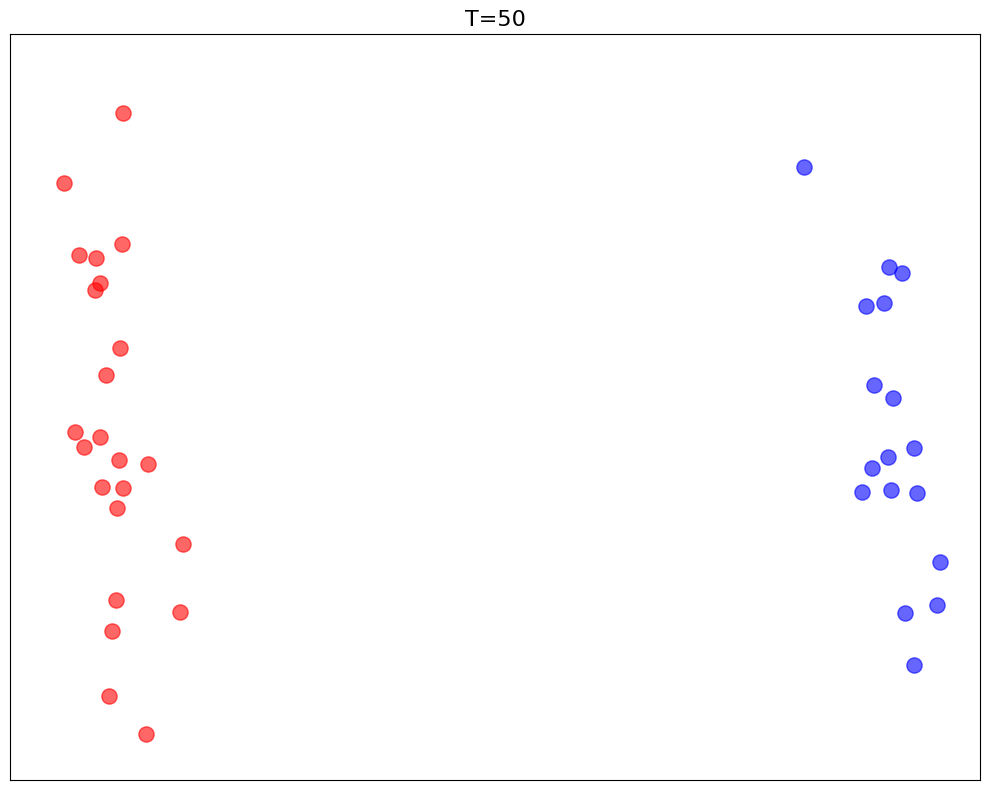

  Processed 100 ground-truth SAT problems...
  Processed 500 ground-truth SAT problems...
  Processed 600 ground-truth SAT problems...
  Processed 900 ground-truth SAT problems...
  Processed 1000 ground-truth SAT problems...

 DECODING RESULTS REPORT
Total True SAT Problems Predicted as SAT: 671
----------------------------------------
Solved by K-Means Dist: 648/671 (96.57%)
Solved by K-Means Init: 650/671 (96.87%)

--- Distance Analysis ---
Mean distance to center (Correctly assigned vars): 14.2543
Mean distance to center (Wrongly assigned vars):   50.7620

--- Classification Report (K-Means on UNSOLVED) ---
                 precision    recall  f1-score   support

Label 0 (False)       0.83      0.84      0.84       942
 Label 1 (True)       0.83      0.83      0.83       898

       accuracy                           0.83      1840
      macro avg       0.83      0.83      0.83      1840
   weighted avg       0.83      0.83      0.83      1840


--- Classification Report (Init on 

In [125]:
# SAT lit 

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

# ==============================================================================
# 1. Verification and Scoring
# ==============================================================================

def count_satisfy(candidate, clauses):
    """Counts how many clauses are satisfied by a given boolean assignment."""
    sat_count = 0
    all_satisfied = True
    
    for clause in clauses:
        lits = np.array(clause)
        idxs = np.abs(lits) - 1
        
        # Check if the literal is satisfied by the current assignment
        is_satisfied = (candidate[idxs] == (lits > 0))
        
        if np.any(is_satisfied):
            sat_count += 1
        else:
            all_satisfied = False
            
    return sat_count, all_satisfied

# ==============================================================================
# 2. Decoding Algorithms
# ==============================================================================

def decode_kmeans_dist(L_emb, clauses, n_vars):
    """Decodes assignments using K-Means and returns the distances to cluster centers."""
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42).fit(L_emb)
    c1, c2 = kmeans.cluster_centers_  

    pos_h = L_emb[:n_vars] 
    neg_h = L_emb[n_vars:] 

    # Calculate distances to centers
    d1 = np.sum((pos_h - c1)**2, axis=1) + np.sum((neg_h - c2)**2, axis=1)
    d2 = np.sum((pos_h - c2)**2, axis=1) + np.sum((neg_h - c1)**2, axis=1)
    
    # Generate Candidate A and its logical inverse, Candidate B
    candidate_A = np.where(d1 > d2, 1, 0)
    candidate_B = 1 - candidate_A

    # Test Candidate A
    cA, solvedA = count_satisfy(candidate_A, clauses) 
    if solvedA:
        return candidate_A, np.where(candidate_A == 1, d2, d1), True
        
    # Test Candidate B
    cB, solvedB = count_satisfy(candidate_B, clauses)
    if solvedB:
        return candidate_B, np.where(candidate_B == 1, d1, d2), True
        
    # If neither solved the problem, return the one that satisfied the most clauses
    if cA >= cB:
        return candidate_A, np.where(candidate_A == 1, d2, d1), False
    return candidate_B, np.where(candidate_A == 1, d2, d1), False


def decode_kmeans_initialisation(L_emb, clauses, n_vars, lit_anchors):
    """Decodes assignments using K-Means seeded with specific initial anchors."""
    # 1. Fit K-Means using anchors (Cluster 0 = False, Cluster 1 = True)
    kmeans = KMeans(n_clusters=2, init=lit_anchors, n_init=1, random_state=42).fit(L_emb)
    
    # 2. kmeans.transform returns the distance to each cluster center
    # Shape is [2 * n_vars, 2]. Column 0 is distance to False, Column 1 is distance to True.
    distances = kmeans.transform(L_emb)
    
    # 3. Isolate the distances to the 'True' cluster (Index 1)
    dist_to_true = distances[:, 1]
    
    # 4. Split into positive and negative literal distances
    pos_dist_to_true = dist_to_true[:n_vars]
    neg_dist_to_true = dist_to_true[n_vars:]
    
    # 5. The Core Logic: If the positive literal is closer to 'True' than 
    # the negative literal is, assign 1 (True). Otherwise, assign 0 (False).
    candidate = np.where(pos_dist_to_true < neg_dist_to_true, 1, 0)
    
    # 6. Verify how many clauses it satisfied
    cA, solved = count_satisfy(candidate, clauses) 
    
    return candidate, solved

# ==============================================================================
# 3. Visualization
# ==============================================================================

def visualize_lit_embeddings(embeddings, labels=None, 
                             label_f='Assigned False (0)', 
                             label_t='Assigned True (1)', 
                             sat=True):
    """Projects literal embeddings down to 2D using PCA and plots them."""
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    if labels is None:
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.6, s=50)
    else:
        sat_indices = np.where(labels == 1)[0]
        unsat_indices = np.where(labels == 0)[0]
        
        plt.scatter(embeddings_2d[unsat_indices, 0], embeddings_2d[unsat_indices, 1], 
                    c='blue', label=label_f, alpha=0.6, s=120)
        plt.scatter(embeddings_2d[sat_indices, 0], embeddings_2d[sat_indices, 1], 
                    c='red', label=label_t, alpha=0.6, s=120)
        # plt.legend(fontsize=12)

    plt.title("T=50", fontsize=16)
    #plt.xlabel("Singular Vector 1", fontsize=12)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

    
    # plt.gca().spines['top'].set_visible(False)
    # plt.gca().spines['right'].set_visible(False)
    # plt.gca().spines['bottom'].set_visible(False)
    # plt.gca().spines['left'].set_visible(False)

    plt.tight_layout()
    plt.xlim(-6, 6)
    plt.ylim(-2, 2)
    #plt.ylabel("Singular Vector 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Ensure LOG_PATH is defined globally, or pass it in
    filename = os.path.join(LOG_PATH, f"Lit_PCA_{'sat' if sat else 'unsat'}.jpg")
    plt.savefig(filename)
    plt.show()

# ==============================================================================
# 4. Main Evaluation Loop
# ==============================================================================

def assignment_decoding(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    # Metrics tracking
    pred_sat = 0
    kmeans_solved = 0
    init_solved = 0
    
    kpred_labels = []
    init_labels = []
    true_labels = []
    
    correct_dist = []
    wrong_dist = []

    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        # We only care about decoding problems that are actually satisfiable
        if not is_sat_ground_truth:
            continue

        vote = votes[i]
        if vote >= 0.5:
            pred_sat += 1

        L_h = lit_emb[i]
        
        # --- Run Decoders ---
        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        init_candidate, init_s = decode_kmeans_initialisation(L_h, clauses, n_vars, lit_anchors)

        assignments = get_close_assignment(k_means_candidate, clauses, n_vars)

        # --- Track Successes ---
        if direct_solved:
            kmeans_solved += 1
            
        if init_s:
            init_solved += 1
        
        if vote < 0.5:
            continue
        # --- Track Distances ---
        correct_dist.append(np.mean(var_dist[(k_means_candidate == assignments)]))
        wrong_dist_list = var_dist[(k_means_candidate != assignments)]
        if len(wrong_dist_list) > 0:
            wrong_dist.append(np.mean(wrong_dist_list))

        # --- Track Labels for F1 Scoring (Only for unsolved problems) ---
        if not direct_solved:
            kpred_labels.extend(k_means_candidate)
            true_labels.extend(assignments)
            init_labels.extend(init_candidate)

        # --- Optional Visualization ---
        if i == 7:
            visualize_lit_embeddings(L_h, assignments)

        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1} ground-truth SAT problems...")

    # ==========================================
    # Print Final Report
    # ==========================================
    print("\n" + "="*40)
    print(" DECODING RESULTS REPORT")
    print("="*40)
    print(f"Total True SAT Problems Predicted as SAT: {pred_sat}")
    print("-" * 40)
    print(f"Solved by K-Means Dist: {kmeans_solved}/{pred_sat} ({(kmeans_solved/max(1, pred_sat))*100:.2f}%)")
    print(f"Solved by K-Means Init: {init_solved}/{pred_sat} ({(init_solved/max(1, pred_sat))*100:.2f}%)")
    
    print("\n--- Distance Analysis ---")
    print(f"Mean distance to center (Correctly assigned vars): {np.mean(correct_dist):.4f}")
    print(f"Mean distance to center (Wrongly assigned vars):   {np.mean(wrong_dist):.4f}")
    
    target_names = ['Label 0 (False)', 'Label 1 (True)']
    
    if len(true_labels) > 0:
        print("\n--- Classification Report (K-Means on UNSOLVED) ---")
        print(classification_report(true_labels, kpred_labels, target_names=target_names))

        print("\n--- Classification Report (Init on UNSOLVED) ---")
        print(classification_report(true_labels, init_labels, target_names=target_names))


# ==============================================================================
# 5. Assignment Confidence
# ==============================================================================
def extract_confident_variable(var_dist):
    mean = np.mean(var_dist)
    std = np.std(var_dist)

    return np.where(var_dist < 0.5 * mean + std)[0]
    
        
def assignment_confidence(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat
    
    conf_acc = []
    conf_count = []
    total = 0
    all_precision = 0
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth:
            continue

        vote = votes[i]
        if vote < 0.5:
            continue
            
        L_h = lit_emb[i]
        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        if direct_solved:
            continue

        total += 1
        assignments = get_close_assignment(k_means_candidate, clauses, n_vars)
        c_idx = extract_confident_variable(var_dist)

        if len(c_idx) > 0:
            correct_count = np.sum(k_means_candidate[c_idx] == assignments[c_idx])
            conf_count.append(len(c_idx))
            acc = correct_count / len(c_idx)
            if correct_count == len(c_idx):
                all_precision += 1
            conf_acc.append(acc)
        
        if (i+1) % 100 == 0:
            print(f"Processed {i+1}...")

    
    print(f"Mean acc of Confidence Var: {np.mean(conf_acc)}")
    print(f"Mean number of Confidence Var: {np.mean(conf_count)}")
    print(f"Number of instances with 100% precision: {all_precision}/{total}")


assignment_decoding()
# assignment_confidence()

In [126]:
# Superivised Assignment Decoding Training

def save_instance(h5_filename, instance_id, embeddings, vote, labels):
    h5_filename = os.path.join(LOG_PATH, h5_filename)
    with h5py.File(h5_filename, 'a') as f:
        grp = f.create_group(f"instance_{instance_id}")
        grp.create_dataset("embeddings", data=embeddings.astype('float32'))
        grp.create_dataset("labels", data=labels.astype('int8'))
        grp.attrs["vote"] = vote


def save_labelled_lit_embedding(test_data_sat="SR(U(10,40))_SAT", test_data_unsat="SR(U(10,40))_UNSAT"):
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_testing_data(test_data_sat, 1)
    data_unsat = read_testing_data(test_data_unsat, 0)
    data = data_sat + data_unsat

    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth:
            continue

        vote = votes[i]
        # all sat instances were used as training data

        L_h = lit_emb[i]
        C_h = clause_emb[i]

        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        if not direct_solved:
            truth_assignment = get_close_assignment(k_means_candidate, clauses, n_vars)
        else:
            truth_assignment = k_means_candidate
        if truth_assignment is None:
            continue
        lit_truth_assignment = np.concatenate([truth_assignment, 1 - truth_assignment])        
        
        save_instance("lit_emb.h5", i, L_h, vote, lit_truth_assignment)

        if (i+1) % 100 == 0:
            print(f"Processed {i+1}...")

#save_labelled_lit_embedding("40_SAT", "40_UNSAT")


#  Assignment Decoding Model + Training
lit_loss_fn = nn.CrossEntropyLoss()
class LiteralDataset(Dataset):
    def __init__(self, h5_file):
        self.all_features = []
        self.all_targets = []

        h5_file = os.path.join(DATA_PATH, h5_file)
        with h5py.File(h5_file, 'r') as f:
            for inst_id in f.keys():
                emb = f[inst_id]['embeddings'][:]
                vote = f[inst_id].attrs['vote']
                labels = f[inst_id]['labels'][:]
                
                # Pre-process features (65D) and tiers
                features = np.hstack((emb, np.full((emb.shape[0], 1), vote)))
                
                self.all_features.append(features)
                self.all_targets.append(labels)
        
        self.X = torch.from_numpy(np.vstack(self.all_features)).float()
        self.y = torch.from_numpy(np.concatenate(self.all_targets)).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class AssignmentDecodingModel(nn.Module):
    def __init__(self, dimension=128, dropout=0.2):
        super(AssignmentDecodingModel, self).__init__()
        # 64 embeddings + 1 Vote = 65 inputs
        self.norm = nn.LayerNorm(65)
        
        self.network = nn.Sequential(
            nn.Linear(65, dimension),
            nn.ReLU(),
            nn.Dropout(dropout), # Prevents overfitting
            nn.Linear(dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # Output: [False, True]
        )
        
    def forward(self, x):
        x = self.norm(x)
        return self.network(x)


def train_epoch_adm(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0
    total_samples = 0 
    
    for i, (features, target) in enumerate(dataloader):
        features, target = features.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        
        outputs = model(features) # Raw logits from the last Linear layer
        loss = lit_loss_fn(outputs, target) 
        
        loss.backward()
        optimizer.step()
                
        batch_size = features.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # if (i + 1) % 100 == 0: 
        #     print(f"--- Epoch {epoch + 1} | Batch {i + 1}/{len(dataloader)} | Loss: {loss.item():.6f}")

    return total_loss / total_samples


def save_checkpoint(epoch, model, optimizer, loss, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, os.path.join(CHECKPOINT_PATH, filename))


def test_adm(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, target in val_loader:
            features, target = features.to(DEVICE), target.to(DEVICE)
            
            outputs = model(features)
            
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
    accuracy = 100 * correct / total
    return accuracy


def log_metrics(model_name, epoch, train_loss, val_acc):
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    log_filename = os.path.join(LOG_PATH, f"{model_name}_training_log.txt")
    is_new_file = not os.path.exists(log_filename)
    
    with open(log_filename, 'a') as f:
        if is_new_file:
            f.write(f"--- Training Log for Model: {model_name} ---\n")
        
        log_line = (
            f"[{timestamp}] Epoch: {epoch:04d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Acc: {val_acc:.6f}\n"
        )
        f.write(log_line)


# training loop
def train_adm_model():
    max_num_epochs = 300
    print(f"Starting Clause Tier Predictor Training on {DEVICE}...")

    model = AssignmentDecodingModel()
    optimizer = optim.Adam(model.parameters(), lr=2e-5)

    max_acc = 0 
    current_epoch = 0
    save_interval = 25
    patience_counter = 0

    full_dataset = LiteralDataset("literal-emb/lit_emb.h5")
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    train_subset, val_subset = random_split(full_dataset, [train_size, val_size])
    train_loader = DataLoader(train_subset, batch_size=1024, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=1024, shuffle=False)
    
    MODEL_NAME = "AssignmentDecodingModel"
    model.to(DEVICE) 
    
    for epoch in range(current_epoch, max_num_epochs):
        avg_loss = train_epoch_adm(model, train_loader, optimizer, epoch)
        print(f"\n--- Epoch {epoch + 1}: Training Loss = {avg_loss:.4f} ---")

        curr_acc = test_adm(model, val_loader)
        print(f"Validation Accuracy: {curr_acc:.4f}\n")

        log_metrics(MODEL_NAME, epoch + 1, avg_loss, curr_acc)
        
        save_this_epoch = False
        saved_name = None
        
        if epoch % save_interval == 0:
            saved_name = f"{MODEL_NAME}_{epoch+1}.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            save_this_epoch = True
            print(f"Saved periodic checkpoint: {saved_name}")
        
        if avg_loss < 0.6:  
            if curr_acc > max_acc:
                max_acc = curr_acc
                patience_counter = 0
        
                if not save_this_epoch: 
                    saved_name = f"{MODEL_NAME}_best.pth"
                    save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
                    print(f"Saved BEST model: {saved_name}")
            else:
                patience_counter += 1

        if patience_counter >= 10:
            print("Early stopping triggered.")
            break

    name = f"{MODEL_NAME}_{epoch}_final.pth"
    save_checkpoint(epoch, model, optimizer, avg_loss, name)

# train_adm_model()


# ADM auto hyperparameter tuning
def objective(trial, data_loader, val_loader):
    # Optuna will explore these values
    dimension = trial.suggest_int("dimension", 64, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = AssignmentDecodingModel(dimension, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    max_num_epochs = 400
    best_acc = 0
    patience_counter = 0
    MODEL_NAME = f"AssignmentDecodingModel-D{dimension}-Dr{dropout}-L{lr}"
    model.to(DEVICE) 

    features, targets = next(iter(data_loader)) # Get one batch
    features, targets = features.to(DEVICE), targets.to(DEVICE)
    
    # with torch.no_grad():
    #     initial_output = model(features)
    #     initial_loss = loss_fn(initial_output, targets)
    #     print(f"Trial {trial.number} Initial Loss (Zero Training): {initial_loss.item():.4f}")

    save_interval = 25
    for epoch in range(max_num_epochs):
        avg_loss = train_epoch_adm(model, data_loader, optimizer, epoch)
        print(f"\n--- Epoch {epoch + 1}: Training Loss = {avg_loss:.4f} ---")

        curr_acc = test_adm(model, val_loader)
        print(f"Validation Accuracy: {curr_acc:.4f}\n")


        log_metrics(MODEL_NAME, epoch + 1, avg_loss, curr_acc)

        if epoch % save_interval == 0:
            saved_name = f"{MODEL_NAME}_{epoch+1}.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            save_this_epoch = True
        
        if curr_acc > best_acc:
            best_acc = curr_acc
            patience_counter = 0
    
            saved_name = f"{MODEL_NAME}_best.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            print(f"Saved BEST model: {saved_name}")
        elif avg_loss < 0.6:
            patience_counter += 1

        # Optuna pruning (all trials)
        trial.report(curr_acc, epoch)
        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}.")
            raise optuna.exceptions.TrialPruned()

        if patience_counter >= 10:
            print("Early stopping triggered.")
            break
    
    return best_acc


def auto_hyperparameter_tuning_adm():
    data_loader = DataLoader(LiteralDataset("literal-emb-full/lit_emb_full.h5"), batch_size=1024, shuffle=True)
    val_loader = DataLoader(LiteralDataset("literal-emb/lit_emb.h5"), batch_size=1024, shuffle=False)

    pruner = SuccessiveHalvingPruner(
        min_resource=5,          # start pruning after 5 epochs
        reduction_factor=3        # halves trials each round
    )
    
    study = optuna.create_study(direction="maximize", pruner=pruner)

    def wrapped_objective(trial):
        return objective(trial, data_loader, val_loader)

    study.optimize(wrapped_objective, n_trials=10)
    
    print("Best trial:")
    print(study.best_params)
    print("Best value:", study.best_value)


# auto_hyperparameter_tuning_adm()

# import shutil

# shutil.make_archive('zipped_NNSAT', 'zip', '/kaggle/working/NNSAT_Project')

# from IPython.display import FileLink
# FileLink(r'zipped_NNSAT.zip')

In [127]:
# Superivised Assignment Decoding Test

# ==============================================================================
# Optimized Dual-Model Inference
# ==============================================================================
def batched_adm_inference(test_data_sat, test_data_unsat, device):
    # 1. Load NeuroSAT
    opts = {'d_model': 64, 'T': 26, 'device': device}
    solver = NeuroSAT(opts)
    solver.restore(LOAD_PATH)
    
    # 2. Load ADM
    adm = AssignmentDecodingModel(dimension=207, dropout=0.1).to(device)
    adm.load_state_dict(torch.load(LOAD_PATH_ADM)['model_state_dict'])
    adm.eval()

    # 3. Setup Data
    sat_data = SATDataset(data_file=test_data_sat, is_training=False, fixed_label=1)
    unsat_data = SATDataset(data_file=test_data_unsat, is_training=False, fixed_label=0)
    merged_data = ConcatDataset([sat_data, unsat_data])
    dataloader = DataLoader(merged_data, batch_size=128, shuffle=False)

    all_graph_votes = []
    all_lit_embs = []
    all_adm_probs = []

    print("Extracting embeddings and running ADM predictions...")
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            
            # --- Pass 1: NeuroSAT ---
            graph_logits, L_h, _, _ = solver.model(batch, return_embeddings=True)
            graph_votes = torch.sigmoid(graph_logits)
            
            # --- Pass 2: ADM (Fully Vectorized) ---
            # Create a list of how many literals belong to each graph in the batch
            n_lits_per_graph = (batch.n_vars * 2).tolist()
            
            # Expand the single graph vote to match every literal in that graph
            expanded_votes = torch.repeat_interleave(graph_votes, torch.tensor(n_lits_per_graph, device=device))
            expanded_votes = expanded_votes.unsqueeze(1) # Shape: [Total_Lits, 1]
            
            # Cat the embeddings with their corresponding expanded votes
            mlp_input = torch.cat([L_h, expanded_votes], dim=1) # Shape: [Total_Lits, 65]
            
            # Run the ADM on the entire batch instantly
            adm_logits = adm(mlp_input)
            adm_probs = torch.softmax(adm_logits, dim=1)
            
            # --- Store Outputs (Moving to CPU) ---
            all_graph_votes.extend(graph_votes.cpu().numpy())
            
            # Split the massive tensors instantly and convert to numpy
            all_lit_embs.extend([emb.numpy() for emb in torch.split(L_h.cpu(), n_lits_per_graph)])
            all_adm_probs.extend([prob.numpy() for prob in torch.split(adm_probs.cpu(), n_lits_per_graph)])
    
    return np.array(all_graph_votes), all_lit_embs, all_adm_probs


# ==============================================================================
# Evaluation & Scoring
# ==============================================================================
def test_adm_pipeline(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Run the fast batched inference
    votes, lit_embs, adm_probs = batched_adm_inference(test_data_sat, test_data_unsat, device)
    
    # Load raw data for evaluation
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    adm_solved_count = 0
    pred_sat_count = 0
    
    pred_class = []
    true_class = []
    
    pred_labels = []
    true_labels = []

    print("\n--- Starting ADM Decoding ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        vote = votes[i]
        
        # Track Graph-Level Satisfiability Prediction
        true_class.append(is_sat_ground_truth)
        pred_class.append(1 if vote >= 0.5 else 0)
            
        # We only decode assignments for ground-truth SAT problems
        if not is_sat_ground_truth:
            continue

        if vote >= 0.5:
            pred_sat_count += 1  
        else:
            continue

        # Grab the ADM predictions for this specific graph
        candidate_prob = adm_probs[i]

        # Compare positive literal truth probability vs negative literal truth probability
        prob_pos_true = candidate_prob[:n_vars, 1]
        prob_neg_true = candidate_prob[n_vars:, 1]
        candidate = (prob_pos_true > prob_neg_true).astype(int)
        
        # Verify assignment
        count, direct_solved = count_satisfy(candidate, clauses) 
        
        if direct_solved:
            adm_solved_count += 1
        else:
            # If it failed, log the labels for the F1 Classification Report
            assignment = get_close_assignment(candidate, clauses, n_vars)
            pred_labels.extend(candidate)
            true_labels.extend(assignment)

        if (i+1) % 100 == 0:
            print(f"Processed {i+1} ground-truth SAT problems...")

    # ==========================================
    # Print Final Report
    # ==========================================
    print("\n" + "="*40)
    print(" ADM DECODING RESULTS REPORT")
    print("="*40)
    print(f"Solved by Supervised ADM: {adm_solved_count}/{pred_sat_count}")
    print("-" * 40)

    target_names = ['Label 0 (False)', 'Label 1 (True)']
    print("\nGraph Satisfiability Classification (NeuroSAT)")
    print(classification_report(true_class, pred_class, target_names=target_names))
    
    if true_labels:
        print("\nLiteral Assignment Classification (ADM on UNSOLVED)")
        print(classification_report(true_labels, pred_labels, target_names=target_names))

# test_adm_pipeline()

In [128]:
# votes

import os
import math
import numpy as np
import matplotlib.pyplot as plt
from pysat.solvers import Minisat22

# ==============================================================================
# 1. PySAT Backbone Utilities
# ==============================================================================

def is_satisfiable(clauses):
    """Quickly checks if a given set of clauses is satisfiable."""
    with Minisat22(bootstrap_with=clauses) as solver:
        return solver.solve()


def get_truth_assignment(clauses):
    """Finds a single satisfying assignment using Minisat."""
    with Minisat22(bootstrap_with=clauses) as solver:
        if solver.solve():
            literals = set(solver.get_model())
            # Convert PySAT model to a binary [0, 1] array
            return [1 if (i + 1) in literals else 0 for i in range(len(literals))]
        return None


def find_backbone(clauses):
    """
    Finds the backbone of a formula by finding one valid model, 
    and then aggressively trying to falsify each literal in that model.
    """
    sat_assignment = get_truth_assignment(clauses)
    if sat_assignment is None:
        return set()

    backbone = []
    for i, is_true in enumerate(sat_assignment):
        var = i + 1
        lit = var if is_true else -var
        
        # If forcing the opposite literal makes it UNSAT, it's a backbone variable
        if not is_satisfiable(clauses + [[-lit]]):
            backbone.append(lit)
            
    return set(backbone)

# ==============================================================================
# 2. Experiment 1: Backbone Confidence Analysis
# ==============================================================================

def backbone_experiment(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    print("Running NN Inference for Backbone Analysis...")
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    all_mean_bb, all_mean_nbb, all_bb_acc = [], [], []
    plot_bb, plot_nbb = [], []
    correct_conf, wrong_conf = [], []

    print("\n--- Starting Backbone Extraction ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth or votes[i] < 0.5:
            continue
            
        L_h = lit_emb[i]
        vvotes = np.array(var_votes[i])

        # Get Predictions & Truth
        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        assignments = get_close_assignment(k_means_candidate, clauses, n_vars)
        
        k_means_candidate = np.array(k_means_candidate)
        
        # Track confidence (magnitude) of correct vs wrong predictions
        correct_conf.extend(np.abs(vvotes[k_means_candidate == assignments]))
        wrong_conf.extend(np.abs(vvotes[k_means_candidate != assignments]))
        
        # Backbone Analysis
        backbone_set = set(abs(x) - 1 for x in find_backbone(clauses))   
        bb_mask = np.array([idx in backbone_set for idx in range(n_vars)])
        nbb_mask = ~bb_mask
        
        bb_vals = vvotes[bb_mask]
        nbb_vals = vvotes[nbb_mask]
    
        # Use np.abs() to measure confidence magnitude, ignoring polarity
        m_bb = bb_vals.mean() if len(bb_vals) > 0 else None
        m_nbb = nbb_vals.mean() if len(nbb_vals) > 0 else None

        if m_bb is not None:
            all_mean_bb.append(m_bb)
            # Accuracy is whether the network polarity matched the PySAT backbone polarity
            # (Assuming vvotes > 0 means True)
            all_bb_acc.append((bb_vals > 0).mean()) 
            
        if m_nbb is not None:
            all_mean_nbb.append(m_nbb)

        if m_bb is not None and m_nbb is not None:
            plot_bb.append(m_bb)
            plot_nbb.append(m_nbb)
    
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} instances...")
    
    # --- Statistics & Plotting ---
    print("\n" + "="*50)
    print(f"{'Global Backbone Statistics':^50}")
    print("="*50)
    print(f"{'Metric':<25} | {'Mean':<10} | {'Std':<10}")
    print("-" * 50)
    print(f"{'BB Vote Magnitude':<25} | {np.mean(all_mean_bb):>10.3f} | {np.std(all_mean_bb):>10.3f}")
    print(f"{'Non-BB Vote Magnitude':<25} | {np.mean(all_mean_nbb):>10.3f} | {np.std(all_mean_nbb):>10.3f}")
    print(f"{'BB Polarity Accuracy':<25} | {np.mean(all_bb_acc)*100:>9.1f}% | {np.std(all_bb_acc)*100:>9.1f}%")
    print("-" * 50)
    print(f"{'Correct Assignment Conf':<25} | {np.mean(correct_conf):>10.3f} | {np.std(correct_conf):>10.3f}")
    print(f"{'Wrong Assignment Conf':<25} | {np.mean(wrong_conf):>10.3f} | {np.std(wrong_conf):>10.3f}")
    print("="*50)
    
    plt.figure(figsize=(8, 8))
    plt.scatter(plot_nbb, plot_bb, alpha=0.5, color='teal', s=20, label='Instances')
    
    high = max(max(plot_bb), max(plot_nbb)) if plot_bb else 8
    low = min(min(plot_bb), min(plot_nbb)) if plot_bb else 0
    plt.plot([low, high], [low, high], color='red', linestyle='--', label='Line of Indifference')
    
    plt.title("Neural Confidence: Backbone vs. Non-Backbone", fontsize=14)
    plt.xlabel("Mean Non-Backbone Vote Magnitude", fontsize=12)
    plt.ylabel("Mean Backbone Vote Magnitude", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    filename = os.path.join(LOG_PATH, "backbone_clustering.jpg")
    plt.savefig(filename, bbox_inches='tight')
    print(f"Saved plot to {filename}")

# ==============================================================================
# 3. Experiment 2: Hamming Distance vs. Confidence
# ==============================================================================

def hamming_distance(pred, truth):
    """Vectorized calculation of percentage difference between two arrays."""
    return np.mean(np.array(pred) != np.array(truth))


def hammingd_experiment(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    print("Running NN Inference for Hamming Distance Analysis...")
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_sat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    # dist_bin format: [[count, total_hamming_distance], ...]
    dist_bin = [[0, 0] for _ in range(10)]
    
    print("\n--- Starting Hamming Distance Evaluation ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth:
            continue

        vote = votes[i]
        L_h = lit_emb[i]
        
        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        
        truth_assignment = k_means_candidate if direct_solved else get_close_assignment(k_means_candidate, clauses, n_vars)

        if direct_solved:
            continue
            
        if truth_assignment is not None:
            hd = hamming_distance(k_means_candidate, truth_assignment)
            
            # Use min(..., 9) to prevent IndexError when vote is exactly 1.0
            idx = min(math.floor(vote * 10), 9)
            dist_bin[idx][0] += 1
            dist_bin[idx][1] += hd

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} instances...")

    print("\n" + "="*50)
    print(f"{'Hamming Distance by Network Confidence':^50}")
    print("="*50)
    
    for idx, (count, total_hd) in enumerate(dist_bin):
        lower_bound = idx * 0.1
        upper_bound = lower_bound + 0.1
        
        if count == 0:
            print(f"Confidence [{lower_bound:.1f} - {upper_bound:.1f}) : N/A (0 problems)")
        else:
            mean_hd = total_hd / count
            print(f"Confidence [{lower_bound:.1f} - {upper_bound:.1f}) : Mean HD = {mean_hd:.4f} | Count = {count}")

# backbone_experiment()
# hammingd_experiment()

In [129]:
# unsat lit

import os
import numpy as np
import matplotlib.pyplot as plt
from pysat.solvers import Minisat22

# ==============================================================================
# 1. UNSAT Core & Propagation Analyzers
# ==============================================================================

def get_unsat_cores(clauses, n_vars):
    """Finds the clauses that make up an UNSAT core using selector variables."""
    with Minisat22() as solver:
        selectors = []
        # Dynamically offset selectors safely above the maximum variable ID
        selector_offset = n_vars + 1 
        
        for i, clause in enumerate(clauses):
            s = selector_offset + i
            solver.add_clause(clause + [s])
            selectors.append(-s)
            
        sat = solver.solve(assumptions=selectors)
        
        if sat: 
            return [] # Should be UNSAT, but safeguard just in case
            
        core = solver.get_core()  
        core_clause_ids = [selectors.index(lit) for lit in core]
        
    return core_clause_ids


def participation_unsat_core(embeddings, participation_counts):
    center = embeddings.mean(axis=0)
    distances = np.linalg.norm(embeddings - center, axis=1)
    
    unique_bins = np.sort(np.unique(participation_counts))
    bin_stats = {}
    
    for count in unique_bins:
        mask = (participation_counts == count)
        bin_dists = distances[mask]
        
        bin_stats[int(count)] = {
            "mean_dist": np.mean(bin_dists),
            "std_dist": np.std(bin_dists),
            "num_literals": len(bin_dists)
        }
        
    return bin_stats


def rank_literal_propagation(embeddings, clauses, n_vars):
    """
    Ranks literals by how many other literals they force via unit propagation.
    Uses a SINGLE solver instance for massive speedup.
    """
    center = embeddings.mean(axis=0)
    distances = np.linalg.norm(embeddings - center, axis=1)

    dist_lc = [0.0, 0.0] # [Count, Total Distance]
    n_conflicts = np.zeros(n_vars * 2)
    lit_conflicts = np.zeros(n_vars * 2)
    
    with Minisat22(bootstrap_with=clauses) as solver:
        for var in range(1, n_vars + 1):
            for lit in (var, -var):
                # propagate() checks forcing under temporary assumptions
                res, prop = solver.propagate(assumptions=[lit])
                
                # Map literal to 0-indexed array [pos_1...pos_n, neg_1...neg_n]
                lit_idx = (lit - 1) if lit > 0 else (n_vars + abs(lit) - 1)
                dist = distances[lit_idx]
                
                if not res:
                    # Direct Conflict: Assuming this literal instantly breaks the formula
                    dist_lc[0] += 1
                    dist_lc[1] += dist
                else:
                    # Successfully propagated 'prop' number of literals
                    count = len(prop)
                    # Safeguard against arrays larger than allocated
                    if count < len(n_conflicts):
                        lit_conflicts[count] += dist
                        n_conflicts[count] += 1
                        
    return lit_conflicts, n_conflicts, dist_lc


def rank_lit_edge_degree(embeddings, clauses, n_vars):
    """Vectorized calculation of literal occurrences (degree) in the graph."""
    center = embeddings.mean(axis=0)
    distances = np.linalg.norm(embeddings - center, axis=1)

    # Flatten clauses and count occurrences instantly
    flat_clauses = np.concatenate(clauses)
    indices = np.where(flat_clauses < 0, 
                       n_vars + np.abs(flat_clauses) - 1, 
                       np.abs(flat_clauses) - 1)
    
    degrees = np.bincount(indices, minlength=n_vars * 2)

    full_degree = np.zeros(100)
    n_degree = np.zeros(100)
    
    for i, deg in enumerate(degrees):
        if deg < 100:  # Prevent index out of bounds for heavily occurring literals
            full_degree[deg] += distances[i]
            n_degree[deg] += 1
            
    return full_degree, n_degree

# ==============================================================================
# 2. Main Experiment Loop
# ==============================================================================

def lit_brittleness_experiment(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    print("Running NN Inference...")
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    # Trackers
    dist_bin = [[] for _ in range(100)]
    n_bin = np.zeros(100)
    
    ranked_dist = np.zeros(40 * 2) 
    ranked_num = np.zeros(40 * 2)

    ranked_degree = np.zeros(100)
    n_degree = np.zeros(100)

    n_lit_direct_conflict = 0
    d_lit_direct_conflict = 0

    print("\n--- Starting Brittleness Extraction ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        # We only want to evaluate UNSAT problems the network correctly identified
        if is_sat_ground_truth or votes[i] >= 0.5:
            continue

        vote = votes[i]
        L_h = lit_emb[i]
        if vote > 0.5:
            continue
        
        # 1. UNSAT Core Participation
        core_indices = get_unsat_cores(clauses, n_vars)
        if len(core_indices) > 0:
            core_lits = np.concatenate([clauses[k] for k in core_indices]) 
            indices = np.where(core_lits < 0, n_vars + np.abs(core_lits) - 1, np.abs(core_lits) - 1)
            participation_counts = np.bincount(indices.astype(int), minlength=n_vars * 2) 
    
            res = participation_unsat_core(L_h, participation_counts)
            for j in res:
                if j < 100: # Safeguard
                    dist_bin[j].append(res[j]["mean_dist"])
                    n_bin[j] += res[j]['num_literals']

        # 2. Literal Propagation Ranking
        rd, rn, lc = rank_literal_propagation(L_h, clauses, n_vars)
        
        # Dynamically pad ranked arrays if n_vars > 40
        if len(rd) > len(ranked_dist):
            ranked_dist = np.pad(ranked_dist, (0, len(rd) - len(ranked_dist)))
            ranked_num = np.pad(ranked_num, (0, len(rn) - len(ranked_num)))
            
        ranked_dist[:len(rd)] += rd
        ranked_num[:len(rn)] += rn
        
        # FIXED: Accumulate conflicts across all graphs!
        n_lit_direct_conflict += lc[0]
        d_lit_direct_conflict += lc[1]

        # 3. Literal Edge Degree
        rd_deg, rn_deg = rank_lit_edge_degree(L_h, clauses, n_vars)
        ranked_degree += rd_deg
        n_degree += rn_deg

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} instances...")

    # ==========================================
    # Print Final Reports
    # ==========================================
    print("\n" + "="*50)
    print(" BRITTLE LITERALS EVALUATION")
    print("="*50)
    
    print("\n--- By UNSAT Core Participation ---")
    for i, c in enumerate(n_bin):
        if c > 0:
            print(f"Participation Count: {i:2d} | Literals: {int(c):4d} | Mean Dist: {np.mean(dist_bin[i]):.4f}")

    print("\n--- By Unit Propagation Count ---")
    prop_means = np.where(ranked_num != 0, ranked_dist / ranked_num, 0)
    # Only print up to the max propagation count we actually observed
    max_prop_idx = np.max(np.nonzero(ranked_num)) if np.any(ranked_num) else 0
    
    for i in range(max_prop_idx + 1):
        if ranked_num[i] > 0:
            print(f"Propagated {i:2d} | Literals: {int(ranked_num[i]):4d} | Mean Dist: {prop_means[i]:.4f}")

    if np.sum(ranked_num) > 0:
        print(f"\nTotal Mean Distance: {np.sum(ranked_dist) / np.sum(ranked_num):.4f}")
        
    if n_lit_direct_conflict > 0:
        print(f"Literals causing direct conflict: {int(n_lit_direct_conflict)}")
        print(f"Mean dist of conflict literals:   {d_lit_direct_conflict / n_lit_direct_conflict:.4f}")

    print("\n--- By Literal Edge Degree ---")
    degree_means = np.where(n_degree != 0, ranked_degree / n_degree, 0)
    max_deg_idx = np.max(np.nonzero(n_degree)) if np.any(n_degree) else 0
    
    for i in range(max_deg_idx + 1):
        if n_degree[i] > 0:
            print(f"Degree {i:2d} | Literals: {int(n_degree[i]):4d} | Mean Dist: {degree_means[i]:.4f}")

# lit_brittleness_experiment()

In [130]:
# unsat_lit

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score

# ==============================================================================
# 1. Clause Embedding Visualization
# ==============================================================================

def visualize_clause_embedding(embeddings, unsat_core_indices=None, satisfied_literals=None, sat=True):
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))

    if sat:
        unique_vals = sorted(list(set(satisfied_literals)))
        cmap = plt.get_cmap('tab10', len(unique_vals))
        bounds = np.array(unique_vals + [unique_vals[-1] + 1]) - 0.5
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                              c=satisfied_literals, cmap=cmap, alpha=0.6, edgecolors='w')
        cbar = plt.colorbar(scatter, ticks=unique_vals)
        cbar.set_label('Number of Satisfied Literals in Clause', fontsize=12)
        cbar.ax.tick_params(labelsize=10)
        
        plt.title("PCA of Clause Embeddings (Satisfiable Instance)", fontsize=14)
        filename = os.path.join(LOG_PATH, "PCA_clause_SAT.jpg")
        
    else:
        # Create color mask: Red for core clauses, Blue for non-core
        colors = ['red' if i in unsat_core_indices else 'blue' for i in range(len(embeddings))]
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                    alpha=0.6, c=colors, edgecolors='k')
        
        plt.title("PCA of Clause Embeddings (Red = UNSAT Core)", fontsize=14)
        filename = os.path.join(LOG_PATH, "PCA_clause_UNSAT.jpg")

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 2. Evaluation Metrics & Clustering Logic
# ==============================================================================

def calculate_metrics(pred, true):
    """Calculates classification metrics safely without zero-division warnings."""
    acc = accuracy_score(true, pred)
    prec = precision_score(true, pred, zero_division=0)
    rec = recall_score(true, pred, zero_division=0)
    return acc, prec, rec
     
def kmeans_clause(embeddings, core_indices):
    num_clauses = len(embeddings)
    
    true_labels = np.zeros(num_clauses)
    if len(core_indices) > 0:
        true_labels[core_indices] = 1
    
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    pred_labels = kmeans.fit_predict(embeddings)

    # Calculate metrics for both possible cluster assignments 
    # (Since K-means arbitrarily assigns 0 and 1)
    acc1, prec1, rec1 = calculate_metrics(pred_labels, true_labels)
    acc2, prec2, rec2 = calculate_metrics(1 - pred_labels, true_labels)

    # Oracle Selection (Best possible match)
    if acc1 > acc2:
        acc_opt, prec_opt, rec_opt = acc1, prec1, rec1
    else:
        acc_opt, prec_opt, rec_opt = acc2, prec2, rec2

    # Cluster Density / Sparsity Analysis
    centroids = kmeans.cluster_centers_
    
    # Measure mean distance to centroid for Cluster 1
    idx1 = np.where(pred_labels == 1)[0]
    sparse_1 = np.mean(np.linalg.norm(embeddings[idx1] - centroids[1], axis=1)) if len(idx1) > 0 else 0
    
    # Measure mean distance to centroid for Cluster 0
    idx0 = np.where(pred_labels == 0)[0]
    sparse_2 = np.mean(np.linalg.norm(embeddings[idx0] - centroids[0], axis=1)) if len(idx0) > 0 else 0
    
    # Density Heuristic: Assume the more "sparse" cluster is the UNSAT Core
    if sparse_1 > sparse_2:
        accd, precd, recd = acc1, prec1, rec1
    else:
        accd, precd, recd = acc2, prec2, rec2    

    return (acc_opt, prec_opt, rec_opt,   # Oracle Best
            acc1, prec1, rec1,            # Always Label 1
            acc2, prec2, rec2,            # Always Label 0 (Inverse)
            accd, precd, recd)            # Sparsity Heuristic

def clause_dist_center(embeddings, core_indices):
    num_clauses = len(embeddings)

    # Find the global center of all clauses
    center = embeddings.mean(axis=0)
    distances = np.linalg.norm(embeddings - center, axis=1)
    
    core_dists = distances[core_indices] if len(core_indices) > 0 else np.array([0])
    
    ncore_indices = [i for i in range(num_clauses) if i not in core_indices]
    ncore_dists = distances[ncore_indices] if len(ncore_indices) > 0 else np.array([0])

    true_labels = np.zeros(num_clauses)
    if len(core_indices) > 0:
        true_labels[core_indices] = 1

    # Simple Thresholding: Identify cores as clauses far away from the center
    threshold = np.mean(distances) + np.std(distances)
    pred_labels = (distances > threshold).astype(int)

    acc, prec, rec = calculate_metrics(pred_labels, true_labels)

    return np.mean(core_dists), np.mean(ncore_dists), np.std(core_dists), acc, prec, rec

# ==============================================================================
# 3. Main Experiment Loop
# ==============================================================================

def unsat_core_experiment(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    print("Running NN Inference for UNSAT Cores...")
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    # Apply the new data reading logic
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    kmeans_result = []
    center_dist_result = []
    
    print("\n--- Starting Core Extraction ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        # We only care about true UNSAT formulas that the network correctly identified
        if is_sat_ground_truth or votes[i] > 0.5:
            continue

        C_h = clause_emb[i]
        
        # Use our safe, dynamically offset selector function
        core_indices = get_unsat_cores(clauses, n_vars)

        # Skip if no core was found (shouldn't happen on true UNSAT, but safe to check)
        if len(core_indices) == 0:
            continue

        if i == 1002: # Or whichever specific graph you want to plot
            print(f"Plotting Graph {i} | Vote: {votes[i]:.4f}")
            visualize_clause_embedding(C_h, unsat_core_indices=core_indices, sat=False)

        # 1. K-Means Clustering Results
        kmeans_res = kmeans_clause(C_h, core_indices)
        kmeans_result.append(kmeans_res)

        # 2. Distance to Center Results
        dist_res = clause_dist_center(C_h, core_indices)
        center_dist_result.append(dist_res)

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} instances...")

    # ==========================================
    # Print Final Reports
    # ==========================================
    kmeans_result = np.array(kmeans_result)
    
    print("\n" + "="*50)
    print(" UNSAT CORE EMBEDDING RESULTS")
    print("="*50)
    
    if len(kmeans_result) == 0:
        print("No valid UNSAT cores were processed. Check your dataset!")
        return

    print('\n--- K-Means on Clause Embeddings ---')
    print(f"{'Method':<30} | {'Acc':<6} | {'Prec':<6} | {'Recall':<6}")
    print("-" * 55)
    print(f"{'Oracle (Best Match)':<30} | {np.mean(kmeans_result[:,0]):.4f} | {np.mean(kmeans_result[:,1]):.4f} | {np.mean(kmeans_result[:,2]):.4f}")
    print(f"{'Label 1 Always':<30} | {np.mean(kmeans_result[:,3]):.4f} | {np.mean(kmeans_result[:,4]):.4f} | {np.mean(kmeans_result[:,5]):.4f}")
    print(f"{'Label 0 Always':<30} | {np.mean(kmeans_result[:,6]):.4f} | {np.mean(kmeans_result[:,7]):.4f} | {np.mean(kmeans_result[:,8]):.4f}")
    print(f"{'Density Heuristic (Sparcer)':<30} | {np.mean(kmeans_result[:,9]):.4f} | {np.mean(kmeans_result[:,10]):.4f} | {np.mean(kmeans_result[:,11]):.4f}")

    center_dist_result = np.array(center_dist_result)
    print('\n--- Distance to Global Center Thresholding ---')
    print(f"Mean Core distance to centroid:     {np.mean(center_dist_result[:,0]):.4f} (Std: {np.std(center_dist_result[:,0]):.4f})")
    print(f"Mean Non-Core distance to centroid: {np.mean(center_dist_result[:,1]):.4f} (Std: {np.std(center_dist_result[:,1]):.4f})")
    print("-" * 55)
    print(f"Accuracy of Core Identification:  {np.mean(center_dist_result[:,3]):.4f}")
    print(f"Precision of Core Identification: {np.mean(center_dist_result[:,4]):.4f}")
    print(f"Recall of Core Identification:    {np.mean(center_dist_result[:,5]):.4f}")
    print("="*50)


# unsat_core_experiment()

In [131]:
# archors

anchors = np.array([
    [-1.0688973665237427, -0.21951384842395782, -0.46788105368614197, 0.8302081227302551, -0.0454467236995697, 0.6869118213653564, 
     0.43211111426353455, -0.5045120716094971, 0.14679738879203796, -1.4756536483764648, -0.3749856948852539, 2.807408332824707, 
     0.007980316877365112, -1.8174999952316284, 0.14887690544128418, -1.4717880487442017, -0.8639873266220093, 0.08314420282840729, 
     0.3478657603263855, -0.650973379611969, 1.0505726337432861, 0.8313286900520325, 0.597281813621521, -0.8978406190872192, -0.06983242183923721, 
     -0.6767086386680603, 0.7024723291397095, -0.48745113611221313, -0.7980130910873413, -1.0489367246627808, -0.262912392616272, 
     0.28391972184181213, -0.39430558681488037, 0.8514984250068665, 1.1722832918167114, -0.501785933971405, 0.30672329664230347, -1.257267951965332, 
     0.7028354406356812, -0.2929333746433258, 2.1056532859802246, 2.5524742603302, -1.8616507053375244, -2.092884063720703, -0.7544057369232178, 
     -0.3862724006175995, 0.079732745885849, 0.10422994196414948, 1.1329216957092285, 0.40780699253082275, 0.10329237580299377, -1.3803635835647583, 
     1.0668517351150513, 1.6234571933746338, 0.8954693675041199, 0.8460555076599121, 0.3137615919113159, 0.3239768147468567, -0.5162566900253296, 
     0.6249728798866272, -0.48900002241134644, -0.07234808802604675, -0.017445452511310577, -0.8922260999679565],
    
    [-1.5279502868652344, 0.3235637843608856, -0.4720613956451416, 1.1833091974258423, -0.20366644859313965, 1.3114039897918701, 0.7232760787010193, 
     -0.35900038480758667, 0.04146215692162514, -2.0341343879699707, 0.7787375450134277, 2.5895705223083496, 0.1882336437702179, -1.4363977909088135, 
     0.13801339268684387, -1.4863892793655396, -0.40857747197151184, 0.042216889560222626, 0.19380693137645721, -1.3005728721618652, 
     0.34111329913139343, 0.05142998695373535, 0.8670247793197632, -0.47594577074050903, 0.006219431757926941, -1.0281274318695068, 
     0.16415943205356598, -0.6184557676315308, -0.42798495292663574, -1.1463019847869873, 0.3335362672805786, -0.20489177107810974, 
     -0.18151524662971497, 1.2750316858291626, 1.3170021772384644, -0.645646870136261, 0.190614253282547, -1.8306357860565186, 0.18610264360904694, 
     -0.18428221344947815, 2.219907283782959, 2.024059295654297, -1.015639305114746, -2.1484124660491943, -0.21311832964420319, -0.3078881502151489, 
     0.016720682382583618, 0.039940718561410904, 1.441049337387085, 0.23558026552200317, -0.0911223292350769, -1.5367647409439087, 
     0.42624956369400024, 1.9830310344696045, 1.0848362445831299, -0.7424460649490356, 0.4697723686695099, 0.1417718529701233, -0.4244024157524109, 
     0.5251449942588806, -0.644385814666748, 0.4455810487270355, 0.00969057809561491, -0.14682269096374512],
    
    [-0.9205459356307983, 0.5068937540054321, -0.30897730588912964, 1.4885197877883911, -0.3312697410583496, 0.7609518766403198, 
     0.8773278594017029, -0.13085158169269562, 0.01613633707165718, -1.9206739664077759, 0.6348748207092285, 2.3576290607452393, 
     0.16138938069343567, -1.3286898136138916, 0.13784661889076233, -1.5230414867401123, -0.25222063064575195, 0.061305854469537735, 
     0.10643445700407028, -1.7906959056854248, 0.05307993292808533, -0.006894350051879883, 1.026405930519104, -0.14851722121238708, 
     -0.4092711806297302, -0.8168495893478394, 0.08391366899013519, -0.38607364892959595, -0.10577154159545898, -1.0019550323486328, 
     0.5971019864082336, -0.09321681410074234, -0.174107164144516, 1.4654673337936401, 0.9603861570358276, -1.1297334432601929, 
     0.12878839671611786, -2.178971290588379, 0.08837005496025085, -0.019934415817260742, 2.349114179611206, 1.6984260082244873, 
     -0.5487681031227112, -2.293565511703491, -0.02514365315437317, -0.2457481324672699, 0.05995485186576843, 0.09765034168958664, 
     1.5366042852401733, 0.1790771484375, -0.028973836451768875, -1.7222709655761719, 0.22677424550056458, 1.858218789100647, 0.7919908761978149, 
     -1.1730715036392212, 0.44154781103134155, 0.12040876597166061, -0.21332620084285736, 0.43571311235427856, -1.0171802043914795, 
     0.6571588516235352, 0.04707786813378334, 0.3010561168193817]
])

In [132]:
# sat_cls

import os
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_distances

# ==============================================================================
# 1. Clause Satisfaction Counter
# ==============================================================================

def clause_satlit_count(clauses, assignment):
    """Highly optimized vectorized counter for satisfied literals per clause."""
    assignment = np.array(assignment)
    lit_sat = []
    
    for c in clauses:
        c_arr = np.array(c)
        var_indices = np.abs(c_arr) - 1
        is_positive = (c_arr > 0)
        
        # A literal is satisfied if it's positive and assignment is 1, 
        # OR if it's negative and assignment is 0
        satisfied = (assignment[var_indices] == is_positive)
        lit_sat.append(np.sum(satisfied))
        
    return np.array(lit_sat)

# ==============================================================================
# 2. Visualization
# ==============================================================================

def visualise_clause_embeddings_with_labels(embeddings, labels=None):
    if labels is None:
        kmeans_model = KMeans(n_clusters=3, n_init=10, random_state=42)
        labels = kmeans_model.fit_predict(embeddings)
        
    pca = PCA(n_components=2)
    sat_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(sat_2d[:, 0], sat_2d[:, 1], 
                          c=labels, cmap='Set1', alpha=0.7, edgecolors='k', s=60)

    legend1 = plt.legend(*scatter.legend_elements(), loc="upper right", title="Clusters")
    plt.gca().add_artist(legend1)

    plt.title("Clause Embedding SAT 3-Cluster Partitioning (K-Means)", fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.4)
    
    filename = os.path.join(LOG_PATH, "PCA_3Cluster_SAT.jpg")
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

# ==============================================================================
# 3. K-Means Clustering Strategies
# ==============================================================================

def map_true_labels(lit_sat):
    """Helper to map satisfaction counts to Tiers: 0 (Brittle), 1 (Medium), 2 (Slack)"""
    return np.where(lit_sat == 1, 0, np.where(lit_sat == 2, 1, 2))

def kmeans_clause_oracle(embeddings, lit_sat):
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    true_labels = map_true_labels(lit_sat)

    max_acc = 0
    pred_labels = []
    
    # Brute-force find the best cluster mapping (Oracle)
    for i, j, k in permutations([0, 1, 2]):
        mapp = [i, j, k]
        cpred_labels = np.array([mapp[lbl] for lbl in labels])
        acc = accuracy_score(true_labels, cpred_labels)
        if acc > max_acc:
            max_acc = acc
            pred_labels = cpred_labels
            
    return true_labels, pred_labels 

def kmeans_clause_similarity(embeddings, lit_sat):
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    center = kmeans.cluster_centers_
    true_labels = map_true_labels(lit_sat)

    # Find the two cluster centers furthest from each other
    dist_matrix = cosine_distances(center)
    idx1, idx2 = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)
    
    all_indices = {0, 1, 2}
    medium_idx = list(all_indices - {idx1, idx2})[0]
    
    d_med_to_idx1 = dist_matrix[medium_idx, idx1]
    d_med_to_idx2 = dist_matrix[medium_idx, idx2]
    
    if d_med_to_idx1 < d_med_to_idx2:
        dense_idx, sparse_idx = idx1, idx2
    else:
        dense_idx, sparse_idx = idx2, idx1

    mapp = [-1, -1, -1]
    mapp[sparse_idx] = 0
    mapp[medium_idx] = 1
    mapp[dense_idx] = 2
    
    pred_labels = np.array([mapp[lbl] for lbl in labels])
    return true_labels, pred_labels 

def kmeans_clause_initialisation(embeddings, lit_sat):
    kmeans = KMeans(n_clusters=3, init=anchors, n_init=1, random_state=42)
    pred_labels = kmeans.fit_predict(embeddings)
    true_labels = map_true_labels(lit_sat)
    return true_labels, pred_labels 

# ==============================================================================
# 4. Main Experiment Loop
# ==============================================================================

def sat_core_experiment(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    print("Running NN Inference for SAT Clause Brittleness...")
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    # Data collectors
    otrue_labels, opred_labels = [], []
    strue_labels, spred_labels = [], []
    itrue_labels, ipred_labels = [], []
    
    print("\n--- Starting Clause Evaluation ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth or votes[i] < 0.5:
            continue

        L_h = lit_emb[i]
        C_h = clause_emb[i]

        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        
        if not direct_solved:
            truth_assignment = get_close_assignment(k_means_candidate, clauses, n_vars)
        else:
            truth_assignment = k_means_candidate
            
        if truth_assignment is None:
            continue
            
        sat_lit_count = clause_satlit_count(clauses, truth_assignment)

        # 1. K-Means Oracle
        true_labels, pred_labels = kmeans_clause_oracle(C_h, sat_lit_count)
        otrue_labels.extend(true_labels)
        opred_labels.extend(pred_labels)

        # 2. K-Means Similarity
        true_labels, pred_labels = kmeans_clause_similarity(C_h, sat_lit_count)
        strue_labels.extend(true_labels)
        spred_labels.extend(pred_labels)

        # 3. K-Means Initialisation
        true_labels, pred_labels = kmeans_clause_initialisation(C_h, sat_lit_count)
        itrue_labels.extend(true_labels)
        ipred_labels.extend(pred_labels)

        if i == 7: 
            print(f"Plotting Graph {i}...")
            visualise_clause_embeddings_with_labels(C_h)

        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} instances...")

    # ==========================================
    # Print Final Reports
    # ==========================================
    target_names = ['Tier 0 (Brittle)', 'Tier 1 (Medium)', 'Tier 2 (Slack)']
    
    print("\n" + "="*55)
    print(" CLAUSE BRITTLENESS EVALUATION (K-MEANS ONLY)")
    print("="*55)
    
    if len(otrue_labels) > 0:
        print("\nK-Means 3-Clustering (Oracle)")
        print(classification_report(otrue_labels, opred_labels, target_names=target_names, zero_division=0))

    if len(strue_labels) > 0:
        print("\nK-Means 3-Clustering (Sorted by Cluster Similarity)")
        print(classification_report(strue_labels, spred_labels, target_names=target_names, zero_division=0))

    if len(itrue_labels) > 0:
        print("\nK-Means 3-Clustering (Anchor Initialised)")
        print(classification_report(itrue_labels, ipred_labels, target_names=target_names, zero_division=0))


# sat_core_experiment()

In [133]:
# CTP training

def save_instance(h5_filename, instance_id, embeddings, vote, labels):
    h5_filename = os.path.join(LOG_PATH, h5_filename)
    with h5py.File(h5_filename, 'a') as f:
        grp = f.create_group(f"instance_{instance_id}")
        grp.create_dataset("embeddings", data=embeddings.astype('float32'))
        grp.create_dataset("labels", data=labels.astype('int8'))
        grp.attrs["vote"] = vote


def save_labelled_clauses_embedding(test_data_sat="SR(U(10,40))_SAT", test_data_unsat="SR(U(10,40))_UNSAT"):
    votes, lit_emb, clause_emb, var_votes, latency = NN_inference(test_data_sat, test_data_unsat)
    
    data_sat = read_testing_data(test_data_sat, 1)
    data_unsat = read_testing_data(test_data_unsat, 0)
    data = data_sat + data_unsat

    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        if not is_sat_ground_truth:
            continue

        vote = votes[i]
        # all sat instances were used as training data

        L_h = lit_emb[i]
        C_h = clause_emb[i]

        k_means_candidate, direct_solved = decode_kmeans(L_h, clauses, n_vars)
        if not direct_solved:
            truth_assignment = get_close_assignment(k_means_candidate, clauses, n_vars)
        else:
            truth_assignment = k_means_candidate
        if truth_assignment is None:
            continue
        sat_lit_count = np.array(clause_satlit_count(clauses, truth_assignment))

        save_instance("clause_emb.h5", i, C_h, vote, sat_lit_count)

        if (i+1) % 100 == 0:
            print(f"Processed {i+1}...")


# save_labelled_clauses_embedding()

clause_loss_fn = nn.CrossEntropyLoss()

class ClauseDataset(Dataset):
    def __init__(self, h5_file):
        self.all_features = []
        self.all_targets = []

        h5_file = os.path.join(DATA_PATH, h5_file)
        with h5py.File(h5_file, 'r') as f:
            for inst_id in f.keys():
                emb = f[inst_id]['embeddings'][:]
                vote = f[inst_id].attrs['vote']
                labels = f[inst_id]['labels'][:]
                
                # Pre-process features (65D) and tiers
                features = np.hstack((emb, np.full((emb.shape[0], 1), vote)))
                tiers = np.where(labels == 1, 0, np.where(labels == 2, 1, 2))
                
                self.all_features.append(features)
                self.all_targets.append(tiers)
        
        self.X = torch.from_numpy(np.vstack(self.all_features)).float()
        self.y = torch.from_numpy(np.concatenate(self.all_targets)).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class ClauseTierPredictor(nn.Module):
    def __init__(self, dimension=128, dropout=0.2):
        super(ClauseTierPredictor, self).__init__()
        # 64 embeddings + 1 Vote = 65 inputs
        self.norm = nn.LayerNorm(65)
        
        self.network = nn.Sequential(
            nn.Linear(65, dimension),
            nn.ReLU(),
            nn.Dropout(dropout), # Prevents overfitting
            nn.Linear(dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 3) # Output: [Brittle, Medium, Slack]
        )
        
    def forward(self, x):
        x = self.norm(x)
        return self.network(x)


def train_epoch_ctp(model, dataloader, optimizer, epoch):
    model.train()
    total_loss = 0
    total_samples = 0 
    
    for i, (features, target) in enumerate(dataloader):
        features, target = features.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        
        outputs = model(features) # Raw logits from the last Linear layer
        loss = clause_loss_fn(outputs, target) 
        
        loss.backward()
        optimizer.step()
                
        batch_size = features.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # if (i + 1) % 100 == 0: 
        #     print(f"--- Epoch {epoch + 1} | Batch {i + 1}/{len(dataloader)} | Loss: {loss.item():.6f}")

    return total_loss / total_samples


def save_checkpoint(epoch, model, optimizer, loss, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, os.path.join(CHECKPOINT_PATH, filename))


def test_ctp(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    val_loss = 0
    
    with torch.no_grad():
        for features, target in val_loader:
            features, target = features.to(DEVICE), target.to(DEVICE)
            
            outputs = model(features)
            loss = clause_loss_fn(outputs, target)
            val_loss += loss.item() * features.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
    accuracy = 100 * correct / total
    return accuracy


def log_metrics(model_name, epoch, train_loss, val_acc):
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    log_filename = os.path.join(LOG_PATH, f"{model_name}_training_log.txt")
    is_new_file = not os.path.exists(log_filename)
    
    with open(log_filename, 'a') as f:
        if is_new_file:
            f.write(f"--- Training Log for Model: {model_name} ---\n")
        
        log_line = (
            f"[{timestamp}] Epoch: {epoch:04d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Acc: {val_acc:.6f}\n"
        )
        f.write(log_line)


# training loop
def train_ctp_model():
    max_num_epochs = 300
    print(f"Starting Clause Tier Predictor Training on {DEVICE}...")

    model = ClauseTierPredictor()
    optimizer = optim.Adam(model.parameters(), lr=2e-5)

    max_acc = 0 
    current_epoch = 0
    save_interval = 25
    patience_counter = 0

    full_dataset = ClauseDataset("clause-emb-full/clause_emb_full.h5")
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    
    train_subset, val_subset = random_split(full_dataset, [train_size, val_size])
    train_loader = DataLoader(train_subset, batch_size=1024, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=1024, shuffle=False)
    
    MODEL_NAME = "ClauseTierPredictor"
    model.to(DEVICE) 
    
    for epoch in range(current_epoch, max_num_epochs):
        avg_loss = train_epoch_ctp(model, train_loader, optimizer, epoch)
        print(f"\n--- Epoch {epoch + 1}: Training Loss = {avg_loss:.4f} ---")

        curr_acc = test_ctp(model, val_loader)
        print(f"Validation Accuracy: {curr_acc:.4f}\n")

        log_metrics(MODEL_NAME, epoch + 1, avg_loss, curr_acc)
        
        save_this_epoch = False
        saved_name = None
        
        if epoch % save_interval == 0:
            saved_name = f"{MODEL_NAME}_{epoch+1}.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            save_this_epoch = True
            print(f"Saved periodic checkpoint: {saved_name}")
        
        if avg_loss < 0.6:  
            if curr_acc > max_acc:
                max_acc = curr_acc
                patience_counter = 0
        
                if not save_this_epoch: 
                    saved_name = f"{MODEL_NAME}_best.pth"
                    save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
                    print(f"Saved BEST model: {saved_name}")
            else:
                patience_counter += 1

        if patience_counter >= 10:
            print("Early stopping triggered.")
            break

    name = f"{MODEL_NAME}_{epoch}_final.pth"
    save_checkpoint(epoch, model, optimizer, avg_loss, name)


# CTP auto hyperparameter tuning


def objective(trial, data_loader, val_loader):
    # Optuna will explore these values
    dimension = trial.suggest_int("dimension", 64, 256)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

    model = ClauseTierPredictor(dimension, dropout)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    max_num_epochs = 400
    best_acc = 0
    patience_counter = 0
    MODEL_NAME = f"ClauseTierPredictor-D{dimension}-Dr{dropout}-L{lr}"
    model.to(DEVICE) 

    features, targets = next(iter(data_loader)) # Get one batch
    features, targets = features.to(DEVICE), targets.to(DEVICE)
    
    # with torch.no_grad():
    #     initial_output = model(features)
    #     initial_loss = loss_fn(initial_output, targets)
    #     print(f"Trial {trial.number} Initial Loss (Zero Training): {initial_loss.item():.4f}")

    save_interval = 25
    for epoch in range(max_num_epochs):
        avg_loss = train_epoch_ctp(model, data_loader, optimizer, epoch)
        print(f"\n--- Epoch {epoch + 1}: Training Loss = {avg_loss:.4f} ---")

        curr_acc = test_ctp(model, val_loader)
        print(f"Validation Accuracy: {curr_acc:.4f}\n")


        log_metrics(MODEL_NAME, epoch + 1, avg_loss, curr_acc)

        if epoch % save_interval == 0:
            saved_name = f"{MODEL_NAME}_{epoch+1}.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            save_this_epoch = True
        
        if curr_acc > best_acc:
            best_acc = curr_acc
            patience_counter = 0
    
            saved_name = f"{MODEL_NAME}_best.pth"
            save_checkpoint(epoch, model, optimizer, avg_loss, saved_name)
            print(f"Saved BEST model: {saved_name}")
        elif avg_loss < 0.6:
            patience_counter += 1

        # Optuna pruning (all trials)
        trial.report(curr_acc, epoch)
        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}.")
            raise optuna.exceptions.TrialPruned()

        if patience_counter >= 10:
            print("Early stopping triggered.")
            break
    
    return best_acc


def auto_hyperparameter_tuning_ctp():
    data_loader = DataLoader(ClauseDataset("clause-emb-full/clause_emb_full.h5"), batch_size=1024, shuffle=True)
    val_loader = DataLoader(ClauseDataset("clause-emb/clause_emb.h5"), batch_size=1024, shuffle=False)

    pruner = SuccessiveHalvingPruner(
        min_resource=5,          # start pruning after 5 epochs
        reduction_factor=3        # halves trials each round
    )
    
    study = optuna.create_study(direction="maximize", pruner=pruner)

    def wrapped_objective(trial):
        return objective(trial, data_loader, val_loader)

    study.optimize(wrapped_objective, n_trials=10)
    
    print("Best trial:")
    print(study.best_params)
    print("Best value:", study.best_value)


# auto_hyperparameter_tuning_ctp()

In [134]:
# CTP test

def load_checkpoint_ctp(model, optimizer, device, filename):
    checkpoint_path = os.path.join(LOAD_PATH_CTP, filename)
    if os.path.exists(checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            model.to(device)
            for state in optimizer.state.values():
                for k, v in state.items():
                    if isinstance(v, torch.Tensor):
                        state[k] = v.to(device)

            print(f"--- Checkpoint loaded. Epoch {checkpoint['epoch'] + 1} ---")
            return checkpoint
        except Exception as e:
            print(f"Error loading checkpoint: {e}")
            return None
    return None

# ==============================================================================
# 1. Optimized Batched Inference
# ==============================================================================

def batched_ctp_inference(test_data_sat, test_data_unsat, device):
    """
    Runs both the NeuroSAT backbone and the Supervised CTP in a single batched pass.
    """
    # 1. Load NeuroSAT
    opts = {'d_model': 64, 'T': 26, 'device': device}
    solver = NeuroSAT(opts)
    solver.restore(LOAD_PATH)

    # 2. Load CTP
    ctp = ClauseTierPredictor(dimension=220, dropout=0.3).to(device)
    ctp.load_state_dict(torch.load(LOAD_PATH_CTP)['model_state_dict'])
    ctp.eval()

    # 3. Setup Data
    sat_data = SATDataset(data_file=test_data_sat, is_training=False, fixed_label=1)
    unsat_data = SATDataset(data_file=test_data_unsat, is_training=False, fixed_label=0)
    merged_data = ConcatDataset([sat_data, unsat_data]) 
    dataloader = DataLoader(merged_data, batch_size=128, shuffle=False)

    all_graph_votes = []
    all_lit_embs = []
    all_clause_embs = []
    all_ctp_probs = []

    print("Extracting embeddings and running CTP predictions...")
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            
            # --- Pass 1: NeuroSAT ---
            graph_logits, L_h, C_h, _ = solver.model(batch, return_embeddings=True)
            graph_votes = torch.sigmoid(graph_logits)
            
            # --- Pass 2: CTP (Fully Vectorized) ---
            # Create a list of how many clauses belong to each graph
            n_clauses_per_graph = batch.n_clauses.tolist()
            
            # Expand the single graph vote to match every clause in that graph
            expanded_votes = torch.repeat_interleave(graph_votes, torch.tensor(n_clauses_per_graph, device=device))
            expanded_votes = expanded_votes.unsqueeze(1) # Shape: [Total_Clauses, 1]
            
            # Cat the clause embeddings with their corresponding expanded votes
            mlp_input = torch.cat([C_h, expanded_votes], dim=1) # Shape: [Total_Clauses, 65]
            
            # Run the CTP on the entire batch instantly
            ctp_logits = ctp(mlp_input)
            ctp_probs = torch.softmax(ctp_logits, dim=1)
            
            # --- Store Outputs (Moving to CPU) ---
            all_graph_votes.extend(graph_votes.cpu().numpy())
            
            n_lits_per_graph = (batch.n_vars * 2).tolist()
            all_lit_embs.extend([emb.numpy() for emb in torch.split(L_h.cpu(), n_lits_per_graph)])
            all_clause_embs.extend([emb.numpy() for emb in torch.split(C_h.cpu(), n_clauses_per_graph)])
            all_ctp_probs.extend([prob.numpy() for prob in torch.split(ctp_probs.cpu(), n_clauses_per_graph)])
    
    return np.array(all_graph_votes), all_lit_embs, all_clause_embs, all_ctp_probs


# ==============================================================================
# 3. Main Evaluation Loop
# ==============================================================================

def test_batch_ctp_model(test_data_sat="Test_40_SAT", test_data_unsat="Test_40_UNSAT"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    votes, lit_emb, clause_emb, ctp_probs = batched_ctp_inference(test_data_sat, test_data_unsat, device)
    
    # Use the new read_data logic
    data_sat = read_data(test_data_sat, is_training=False, fixed_label=1)
    data_unsat = read_data(test_data_unsat, is_training=False, fixed_label=0)
    data = data_sat + data_unsat

    all_true_tiers = []
    all_pred_tiers = []
    
    print("\n--- Starting CTP Evaluation ---")
    for i, (clauses, n_vars, is_sat_ground_truth) in enumerate(data):
        # We only care about ground-truth SAT problems where the model is confident
        if not is_sat_ground_truth or votes[i] < 0.5:
            continue

        L_h = lit_emb[i]
        tier_prob = ctp_probs[i]

        k_means_candidate, var_dist, direct_solved = decode_kmeans_dist(L_h, clauses, n_vars)
        
        if not direct_solved:
            truth_assignment = get_close_assignment(k_means_candidate, clauses, n_vars)
        else:
            truth_assignment = k_means_candidate
            
        if truth_assignment is None:
            continue
            
        # Use our vectorized satisfaction counter
        sat_lit_count = clause_satlit_count(clauses, truth_assignment)

        # Map to tiers
        tiers = np.where(sat_lit_count == 1, 0, np.where(sat_lit_count == 2, 1, 2))
        p_tiers = np.argmax(tier_prob, axis=1)

        all_true_tiers.extend(tiers)
        all_pred_tiers.extend(p_tiers)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} ground-truth SAT problems...")

    # ==========================================
    # Print Final Report
    # ==========================================
    print("\n" + "="*50)
    print(" CTP TIER PREDICTION REPORT")
    print("="*50)
    
    if len(all_true_tiers) > 0:
        target_names = ['Tier 0 (Brittle)', 'Tier 1 (Medium)', 'Tier 2 (Slack)']
        print(classification_report(all_true_tiers, all_pred_tiers, target_names=target_names, zero_division=0))
    else:
        print("No valid instances were processed to generate a report.")

# test_batch_ctp_model()